In [1]:
import pandas as pd
import numpy as np
import cpi
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from scipy import stats

# %pip install scipy

## IMPORTAR DATASETS

In [3]:
# Load Dataframes
print("Loading Clean Data Files...")

CLEAN_FILE_FACTS = 'data/clean_facts_df.pkl'
CLEAN_FILE_SONGS = 'data/clean_songs_df.pkl'
CLEAND_FILE_FILMS = 'data/clean_films_df.pkl'
CLEAN_FILE_ARTISTS = 'data/clean_artists_df.pkl'
CLEAN_FILE_ROLES = 'data/clean_roles_df.pkl'

df_facts_clean = pd.read_pickle(CLEAN_FILE_FACTS)
df_songs_clean = pd.read_pickle(CLEAN_FILE_SONGS)
df_films_clean = pd.read_pickle(CLEAND_FILE_FILMS)
df_artists_clean = pd.read_pickle(CLEAN_FILE_ARTISTS)
df_roles_clean = pd.read_pickle(CLEAN_FILE_ROLES)

print("Data loaded! Ready for analysis...")
display(df_facts_clean.head())

print(f"df_songs_clean shape: {df_songs_clean.shape}")
print(f"df_films_clean shape: {df_films_clean.shape}")
print(f"df_facts_clean shape: {df_facts_clean.shape}")
print(f"df_artists_clean shape: {df_artists_clean.shape}")
print(f"df_roles_clean shape: {df_roles_clean.shape}")

Loading Clean Data Files...
Data loaded! Ready for analysis...


,song_id,year,song_title,film_title,film_id
0,193401,1934,The Continental,The Gay Divorcee,193401
1,193402,1934,Love In Bloom,She Loves Me Not,193402
2,193501,1935,Lullaby Of Broadway,Gold Diggers of 1935,193501
3,193502,1935,Cheek To Cheek,Top Hat,193502
4,193503,1935,Lovely To Look At,Roberta,193503


df_songs_clean shape: (497, 62)
df_films_clean shape: (467, 50)
df_facts_clean shape: (500, 5)
df_artists_clean shape: (602, 25)
df_roles_clean shape: (2042, 5)


## ANÁLISIS DESCRIPTIVA

In [4]:
df_songs_aux = df_songs_clean.copy()
df_films_aux = df_films_clean.copy()

Configuración para los gráficos

In [2]:
# Set publication-ready visualization parameters
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.autolayout': True
})

### Top Songs según Spotify Streams

In [5]:
display(df_songs_aux.nlargest(10, 'streams_obs_max')[['song_id', 'song_title', 'original_artists', 'streams_obs_max', 'lastfm_track_listeners']])

,song_id,song_title,original_artists,streams_obs_max,lastfm_track_listeners
461,201812,Sunflower,"Post Malone, Swae Lee",4319245000,34953
361,199812,Iris,The Goo Goo Dolls,3522534000,1099531
456,201801,Shallow,"Lady Gaga, Bradley Cooper",3118711700,950176
457,201802,All The Stars,"Kendrick Lamar, SZA",3066500000,77263
378,200201,Lose Yourself,Eminem,2948917000,1821799
341,199513,Gangsta's Paradise,Coolio,2574270000,1738729
445,201512,See You Again,"Wiz Khalifa, Charlie Puth",2457387600,22073
423,201112,A Thousand Years,Christina Perri,2323451000,1070876
433,201312,Young And Beautiful,Lana Del Rey,2178070000,2128205
441,201502,Earned It,The Weeknd,2172687000,47091


### Top Songs según LastFM

In [6]:
display(df_songs_aux.nlargest(10, 'lastfm_track_playcount')[['song_id', 'song_title', 'original_artists', 'streams_obs_max', 'lastfm_track_playcount']])

,song_id,song_title,original_artists,streams_obs_max,lastfm_track_playcount
433,201312,Young And Beautiful,Lana Del Rey,2178070000,27523807
413,200813,Decode,Paramore,554516000,23012818
492,202501,Golden,"EJAE, HUNTR/X, REI AMI, AUDREY NUNA",1813500000,18159669
453,201702,Mystery Of Love,Sufjan Stevens,793165000,15897935
378,200201,Lose Yourself,Eminem,2948917000,14466366
424,201201,Skyfall,Adele,1393000000,14141154
341,199513,Gangsta's Paradise,Coolio,2574270000,13017566
192,197312,Knockin' On Heaven's Door,Bob Dylan,1081700000,12357938
250,198203,Eye Of The Tiger,Survivor,1833600000,12100798
239,198013,Call Me,Blondie,771783000,11563792


### Top Films según Revenue

In [7]:
display(df_films_aux.nlargest(10, 'revenue_adjusted')[['film_id', 'film_title', 'film_directors', 'revenue_adjusted']])

,film_id,film_title,film_directors,revenue_adjusted
41,194203,Bambi,David D. Hand,5282376553
326,199701,Titanic,James Cameron,4541627542
23,194001,Pinocchio,Ben Sharpsteen,3771332286
159,196704,The Jungle Book,Wolfgang Reitherman,3643546527
74,195002,Cinderella,"Hamilton Luske, Wilfred Jackson",3521335054
418,201512,Furious 7,James Wan,2058385779
363,200301,The Lord of the Rings: The Return of the King,Peter Jackson,1957709101
216,197802,Grease,Randal Kleiser,1956697971
437,201904,Frozen II,"Chris Buck, Jennifer Lee",1830590280
402,201301,Frozen,"Chris Buck, Jennifer Lee",1760951122


In [8]:
display(df_films_aux.nlargest(10, 'movie_popularity')[['film_id', 'film_title', 'film_directors', 'movie_popularity']])

,film_id,film_title,film_directors,movie_popularity
363,200301,The Lord of the Rings: The Return of the King,Peter Jackson,89.94
355,200104,The Lord of the Rings: The Fellowship of the Ring,Peter Jackson,88.94
331,199712,Life Is Beautiful,Roberto Benigni,85.97
261,198503,Back to the Future,Robert Zemeckis,84.97
311,199401,The Lion King,"Roger Allers, Rob Minkoff",84.96
423,201612,Your Name,Makoto Shinkai,84.03
433,201812,Spider-Man: Into The Spider-Verse,"Bob Persichetti, Peter Ramsey, Rodney Rothman",84.0
327,199702,Good Will Hunting,Gus Van Sant,83.97
384,200802,WALL·E,Andrew Stanton,83.96
424,201701,Coco,Lee Unkrich,83.94


### Canciones por Década

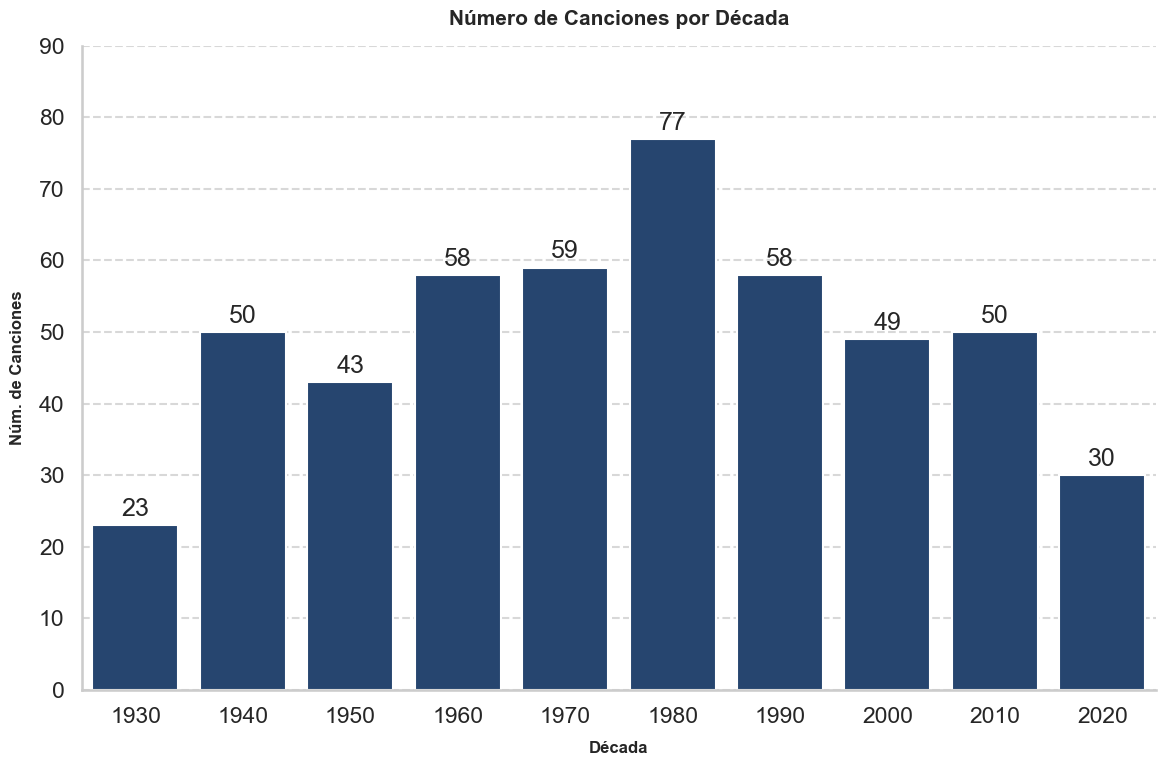

In [10]:
# Songs by Decade plot

plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df_songs_aux, x='decade', color='#1A437B')
ax.bar_label(ax.containers[0], padding=3)

ax.set_xlabel('Década', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. de Canciones', fontsize=12, fontweight='bold', labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.set_ylim(0, 90)

plt.title('Número de Canciones por Década', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()

plt.savefig('plots/songs_count_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()

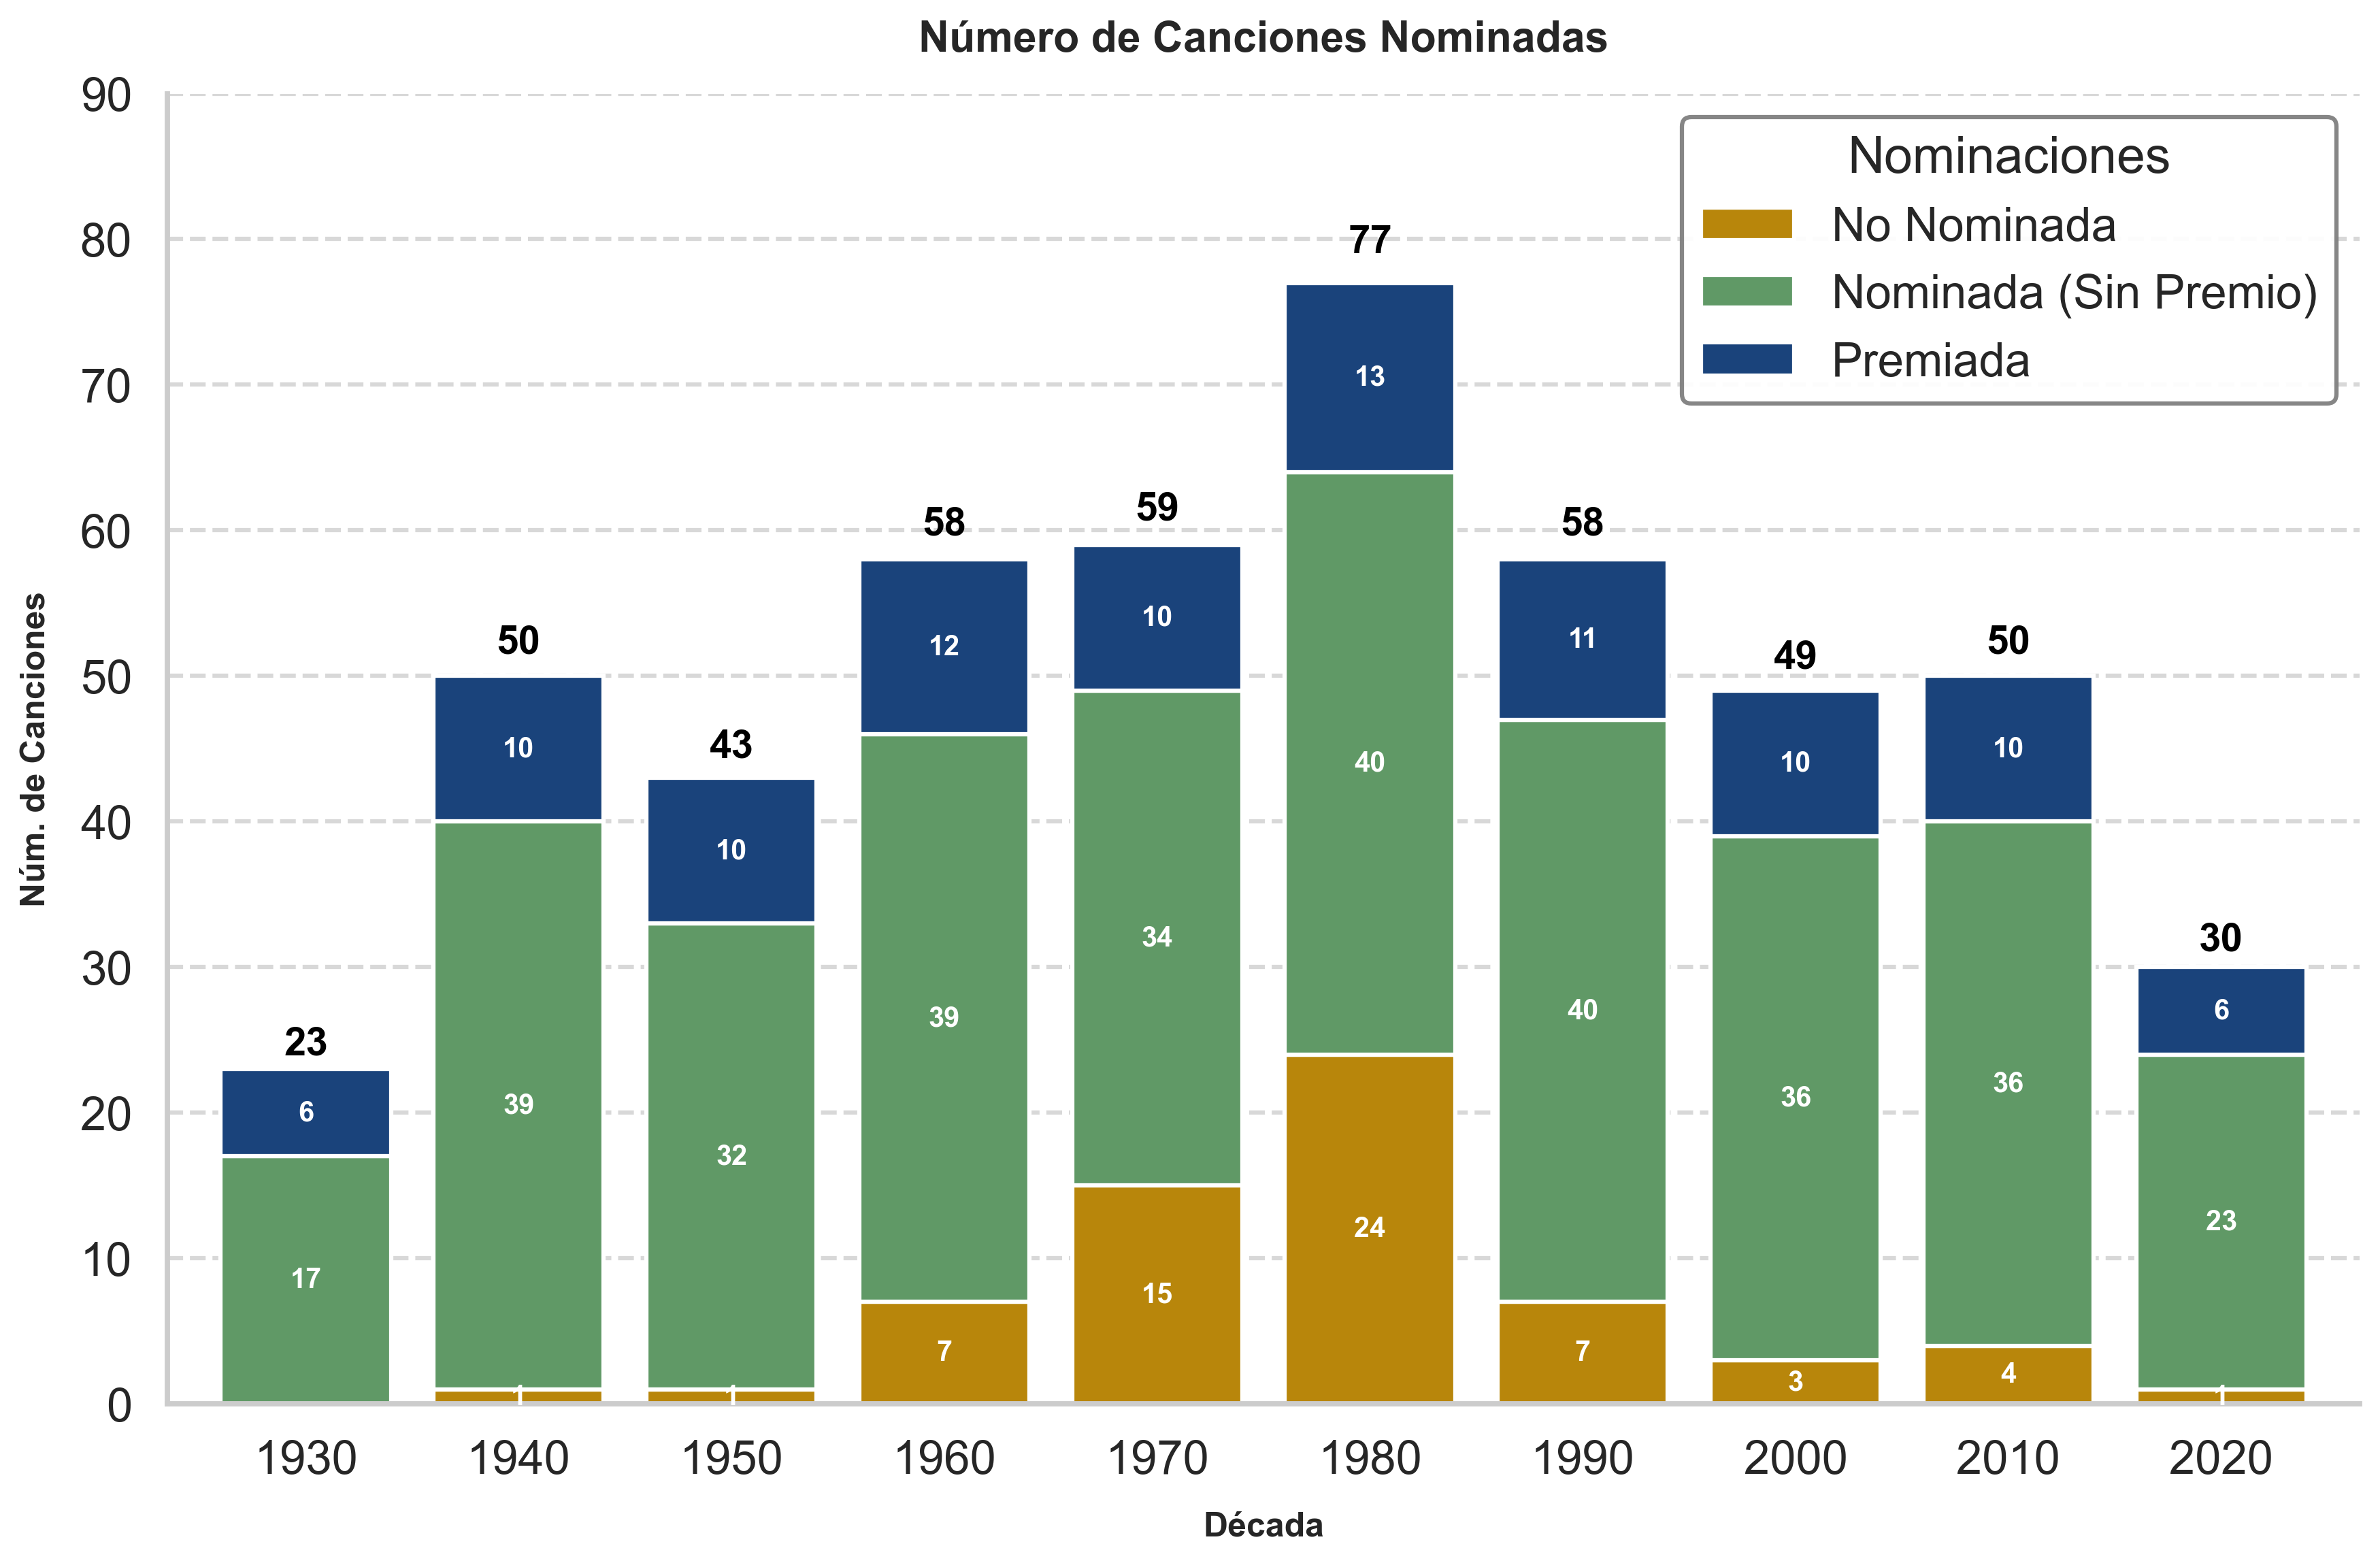

In [ ]:
# Song Counts by Decade with Awards Nominations

# Define the conditions for the three tiers
conditions = [
    # Tier 1: Won at least one award
    (df_songs_aux['song_major_awards'] > 0),
    
    # Tier 2: Nominated, but 0 awards
    ((df_songs_aux['oscar_song_nominee'] == True) |
     (df_songs_aux['grammy_song_nominee'] == True) |
     (df_songs_aux['grammy_record_nominee'] == True)) & 
    (df_songs_aux['song_major_awards'] == 0)
]

choices = ['Premiada', 'Nominada (Sin Premio)']

# Tier column
df_songs_aux['award_tier'] = np.select(conditions, choices, default='No Nominada')

# Crosstab
counts_decade = pd.crosstab(df_songs_aux['decade'], df_songs_aux['award_tier'])

# Force the exact stacking order from bottom to top
ordered_cols = ['No Nominada', 'Nominada (Sin Premio)', 'Premiada']
for col in ordered_cols:
    if col not in counts_decade.columns:
        counts_decade[col] = 0
counts_decade = counts_decade[ordered_cols]

# Plot the stacked chart
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

colors = ['#B8860B', '#609966', '#1A437B']

counts_decade.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors, 
    width=0.8
)

# Add the labels (Inner counts)
for c in ax.containers:
    labels = [str(int(v.get_height())) if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold', fontsize=10)

# Add the top totals
totals = counts_decade.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + (total * 0.02), str(int(total)), 
            ha='center', va='bottom', weight='bold', color='black', fontsize=14)

# MATCH PLOT 1 EXACTLY: Labels, Titles, and Padding
ax.set_xlabel('Década', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. de Canciones', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Número de Canciones Nominadas', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=0)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)
ax.set_ylim(0, 90)

plt.legend(
    title='Nominaciones', 
    loc='upper right', 
    frameon=True,       
    facecolor='white',  
    framealpha=0.95,    
    edgecolor='gray'    
)

plt.tight_layout()
plt.savefig('plots/songs_count_by_decade_awarded.png', dpi=300, bbox_inches='tight')
plt.show()

### Grabaciones por Décadas

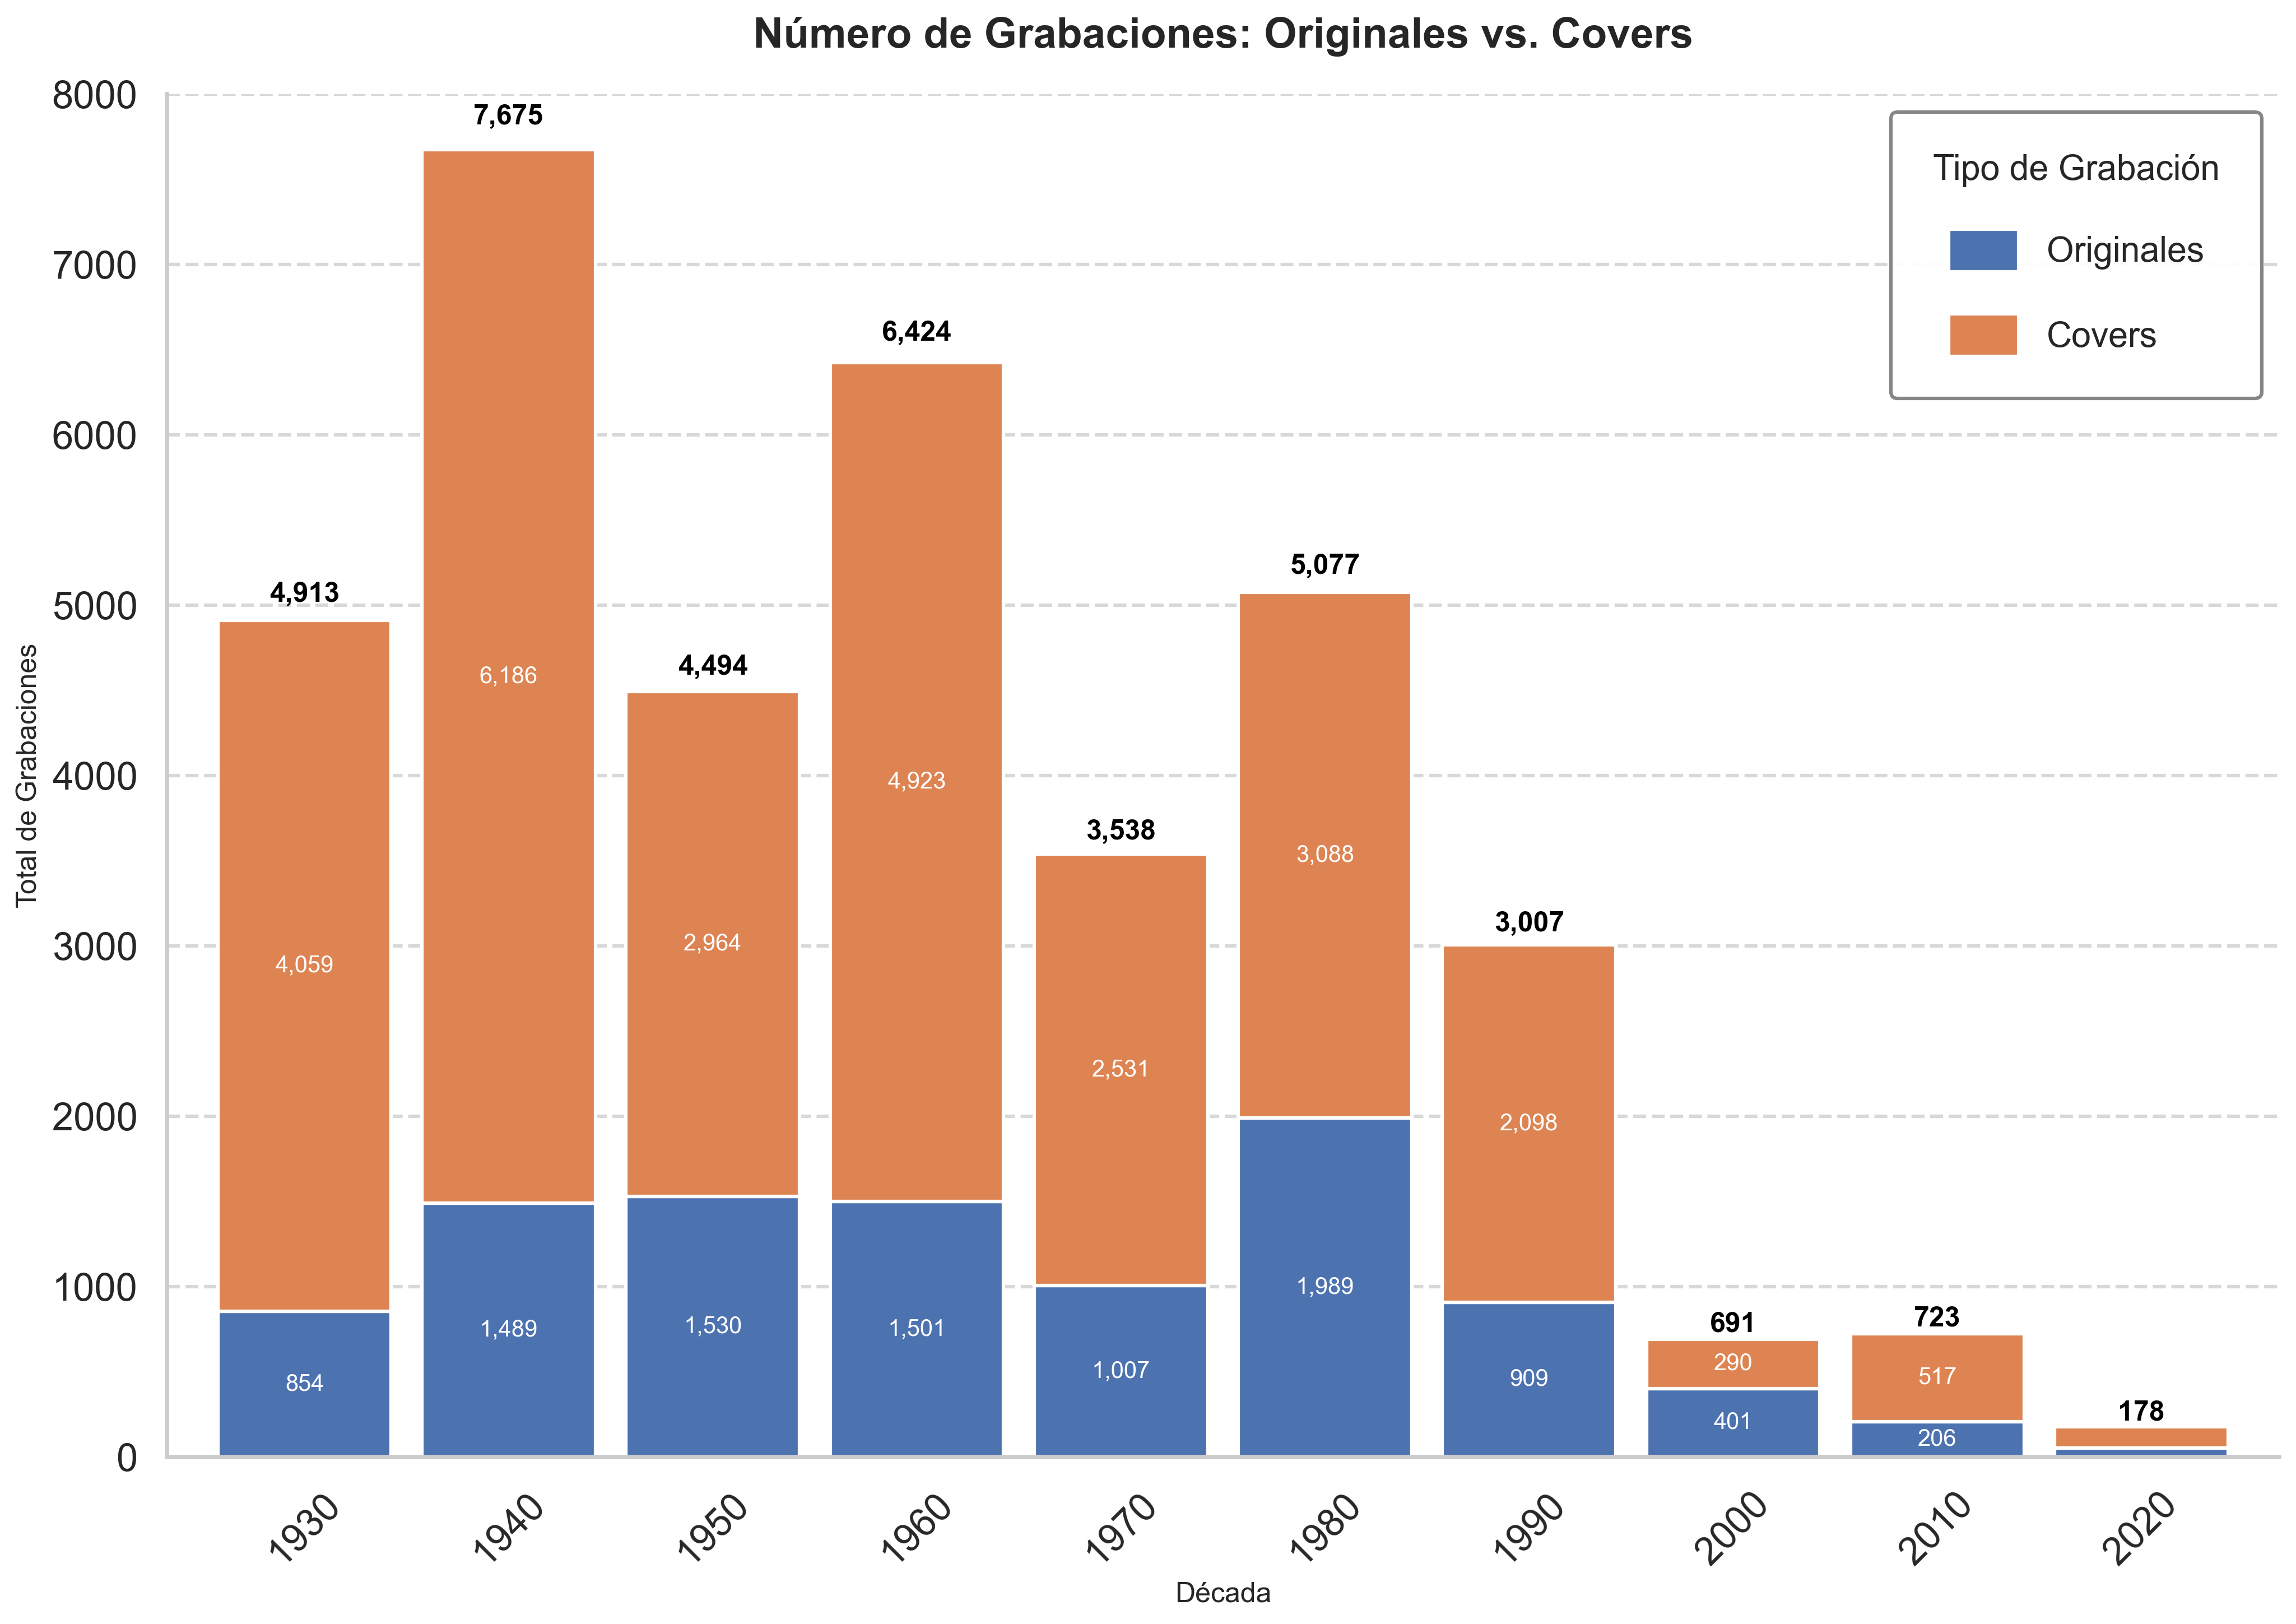

In [ ]:
# Group the data by decade and sum the raw counts
decade_summary = df_songs_aux.groupby('decade')[
    ['mb_original_recordings_count', 'mb_cover_recordings_count']
].sum()

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

decade_summary.plot(
    kind='bar', 
    stacked=True, 
    ax=ax,
    color=['#4C72B0', '#DD8452'], # Muted blue and orange
    width=0.85
)

# Inner labels (Raw numbers instead of percentages)
for container in ax.containers:
    labels = [f"{int(v.get_height()):,}" if v.get_height() > 150 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='white', weight='light', fontsize=10)

# Total counts above the bars
totals = decade_summary.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(
        i, 
        total + (total * 0.015), # Slight offset above the top of the bar
        f"{int(total):,}",       # Formatted with commas
        ha='center', 
        va='bottom', 
        weight='bold', 
        color='black', 
        fontsize=12
    )

# Clean up formatting and spacing
ax.margins(y=0.15) # Give vertical breathing room for the totals and the hovering legend

plt.title('Número de Grabaciones: Originales vs. Covers', fontsize=18, weight='bold', pad=20)
plt.xlabel('Década', fontsize=12)
plt.ylabel('Total de Grabaciones', fontsize=12)
plt.xticks(rotation=45)

# Floating, enlarged legend in the upper right
plt.legend(
    ['Originales', 'Covers'], 
    title='Tipo de Grabación', 
    loc='upper right', 
    fontsize=15,            # Makes the label text larger
    title_fontsize=15,      # Makes the legend title larger
    handlelength=2.0,       # Makes the colored indicator boxes wider
    handleheight=1.5,       # Makes the colored indicator boxes taller
    borderpad=1.2,          # Adds breathing room inside the legend box
    labelspacing=1.2,       # Adds vertical space between the rows
    frameon=True,
    facecolor='white',
    framealpha=0.95,
    edgecolor='gray'
)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)
ax.set_ylim(0, 8000)

plt.tight_layout()
plt.savefig('plots/originals_vs_covers_decades.png', dpi=300, bbox_inches='tight')
plt.show()

### Films por Década

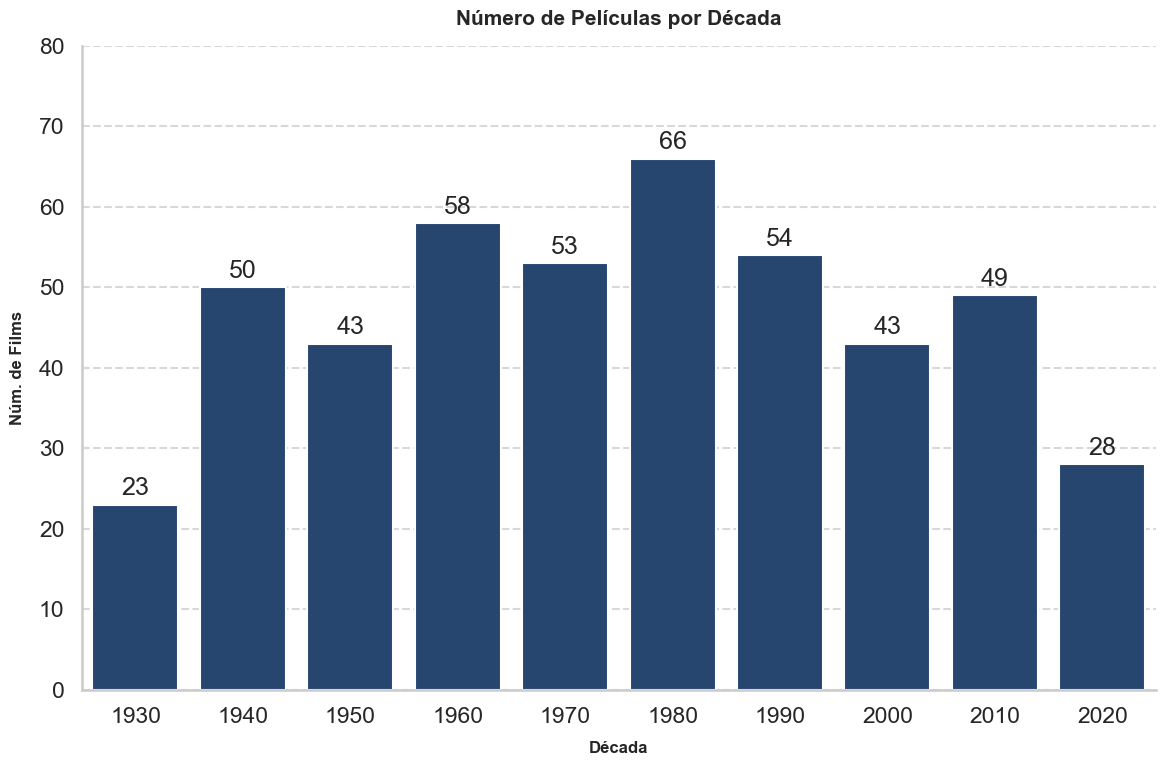

In [58]:
df_films_aux['decade'] = (df_films_aux['year'] // 10) * 10

plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df_films_aux, x='decade', color='#1A437B')
ax.bar_label(ax.containers[0], padding=3)

ax.set_xlabel('Década', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. de Films', fontsize=12, fontweight='bold', labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.set_ylim(0, 80)

plt.title('Número de Películas por Década', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()

plt.savefig('plots/films_count_by_decade.png', dpi=300, bbox_inches='tight')

### Canciones según Premios

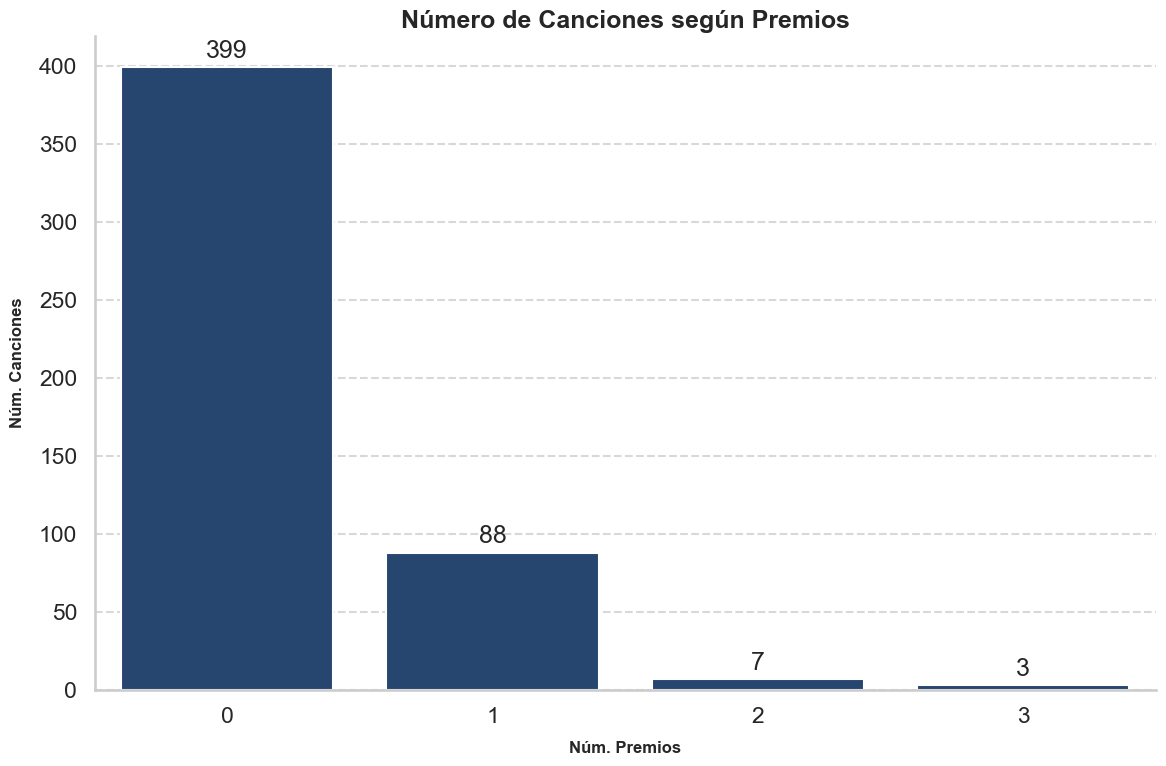

In [48]:
# Songs Count by Song Awards
plt.figure(figsize=(12, 8))

ax = sns.countplot(data=df_songs_aux, x='song_major_awards', color='#1A437B')
ax.bar_label(ax.containers[0], padding=3)

ax.set_xlabel('Núm. Premios', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. Canciones', fontsize=12, fontweight='bold', labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)

plt.title('Número de Canciones según Premios')
plt.tight_layout()

plt.savefig('plots/songs_count_total.png', dpi=300, bbox_inches='tight')
plt.show()

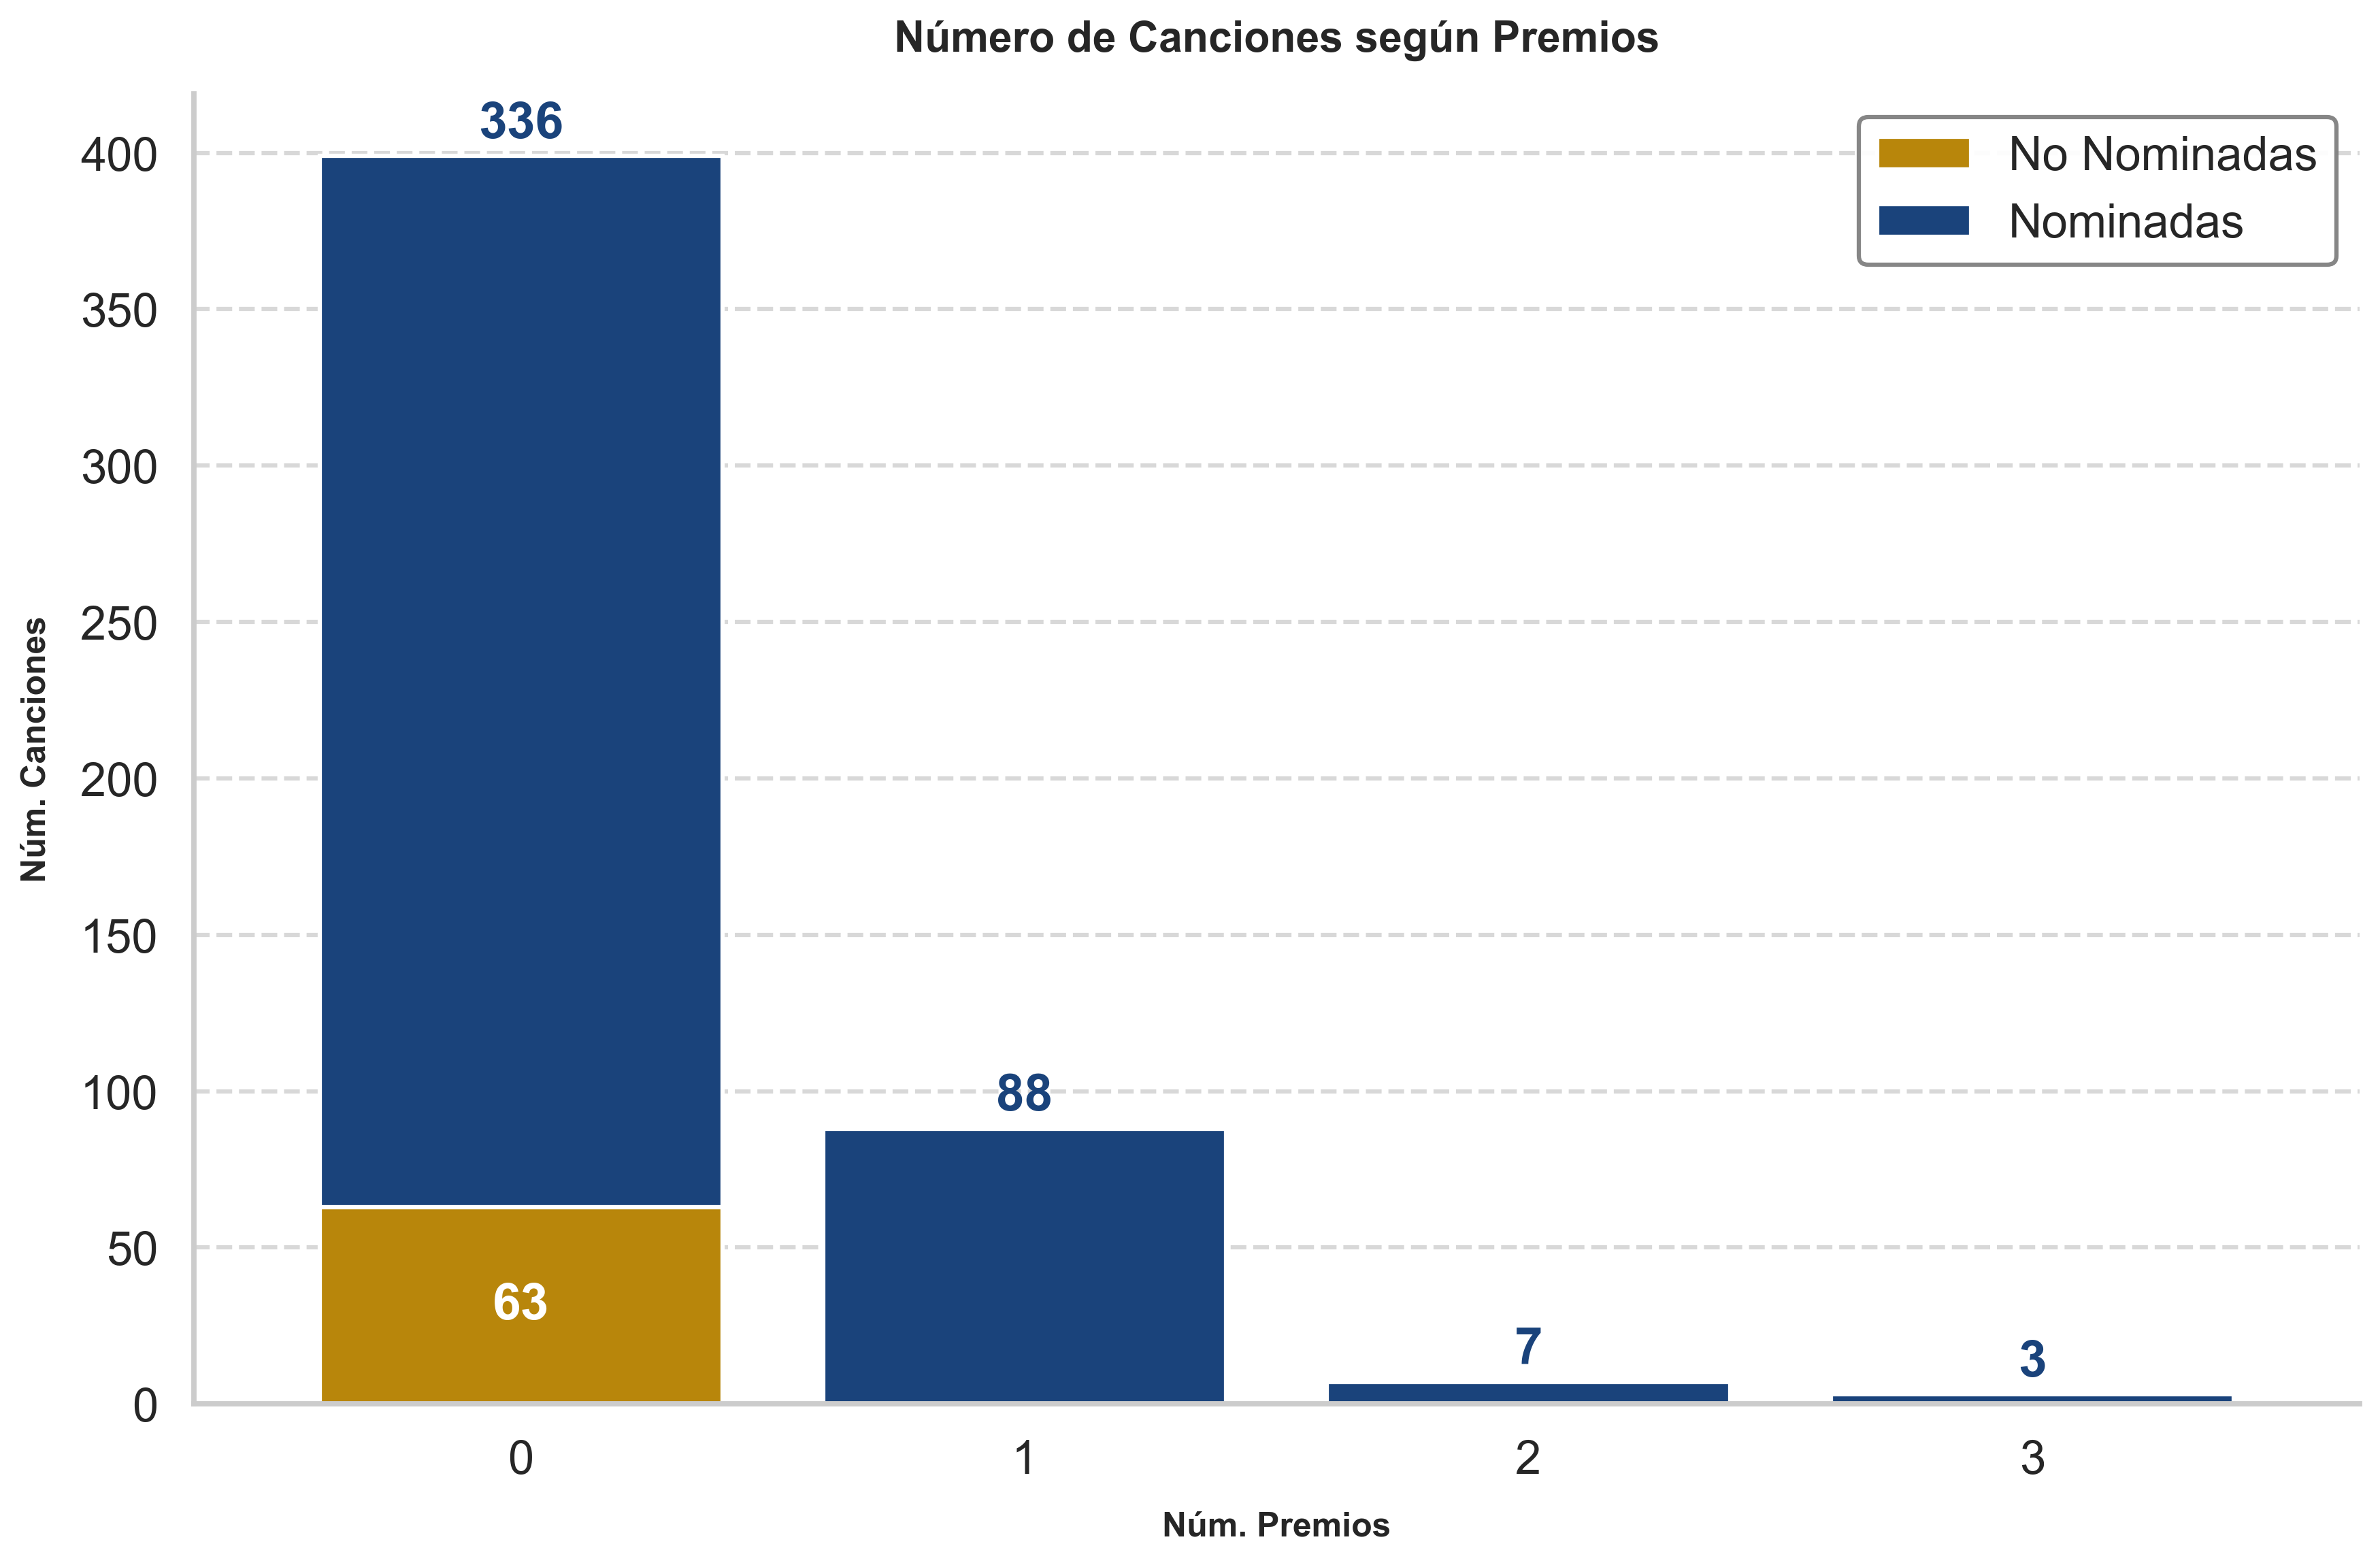

In [ ]:
# Boolean mask (in case winners aren't flagged as nominees)
has_nomination = (
    (df_songs_aux['oscar_song_nominee'] == True) |
    (df_songs_aux['grammy_song_nominee'] == True) |
    (df_songs_aux['grammy_record_nominee'] == True) |
    (df_songs_aux['song_major_awards'] > 0)
)

# Auxiliary column for the split
nom_label = 'Nominadas'
no_nom_label = 'No Nominadas'

df_songs_aux['nomination_status'] = np.where(has_nomination, nom_label, no_nom_label)

# Crosstab
counts = pd.crosstab(df_songs_aux['song_major_awards'], df_songs_aux['nomination_status'])

# Ensure columns are in the right order
if no_nom_label not in counts.columns:
    counts[no_nom_label] = 0
counts = counts[[no_nom_label, nom_label]] 

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8), dpi=300) 

counts.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=['#B8860B', '#1A437B'], # Matte yellow for No Noms, Dark Blue for Noms/Wins
    width=0.8
)

# Centered labels to each block in the stack
for i, c in enumerate(ax.containers):
    # Hide "0" values so they don't clutter the chart
    labels = [str(int(v.get_height())) if v.get_height() > 0 else '' for v in c]
    
    if i == 0:
        # BOTTOM BLOCK (No Nominations): Label in the center, white text
        ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')
    else:
        # TOP BLOCK (At Least 1 Nomination): Label above the column, dark blue text
        ax.bar_label(c, labels=labels, label_type='edge', padding=3, color='#1A437B', weight='bold')

ax.set_xlabel('Núm. Premios', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. Canciones', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Número de Canciones según Premios', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=0)
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)

# Floating Legend (Inside the plot area)
plt.legend(
    # title='Estado', 
    loc='upper right',  # Keeps it hovering inside the top right corner
    frameon=True,       # Draws the box
    facecolor='white',  # Solid white background
    framealpha=0.95,    # Mostly opaque so grid lines don't show through
    edgecolor='gray'    # Soft gray border
)

plt.tight_layout()
plt.savefig('plots/songs_count_by_awards.png', dpi=300, bbox_inches='tight')
plt.show()

### Films por Géneros

In [ ]:
# print(df_films_aux[['tmdb_genres']].head(10))

# Column to be text strings
genres_str = df_films_aux['tmdb_genres'].astype(str)
genres_clean = genres_str.str.replace(r"[\[\]'\"]", "", regex=True)

genres_exploded = genres_clean.str.split(',').explode()
genres_exploded = genres_exploded.str.strip()
genres_exploded = genres_exploded[~genres_exploded.isin(["", "nan", "NaN", "None"])]
genres_exploded = genres_exploded.dropna()

# Get the top 20 Genres
top_20_genres = genres_exploded.value_counts().head(20)
print(top_20_genres)

tmdb_genres
Drama              212
Comedy             203
Romance            182
Music              108
Adventure           99
Family              70
Action              59
Thriller            51
Fantasy             50
Animation           50
Crime               30
History             25
Western             21
Science Fiction     15
Documentary         11
Mystery             10
War                 10
Horror               8
Name: count, dtype: int64


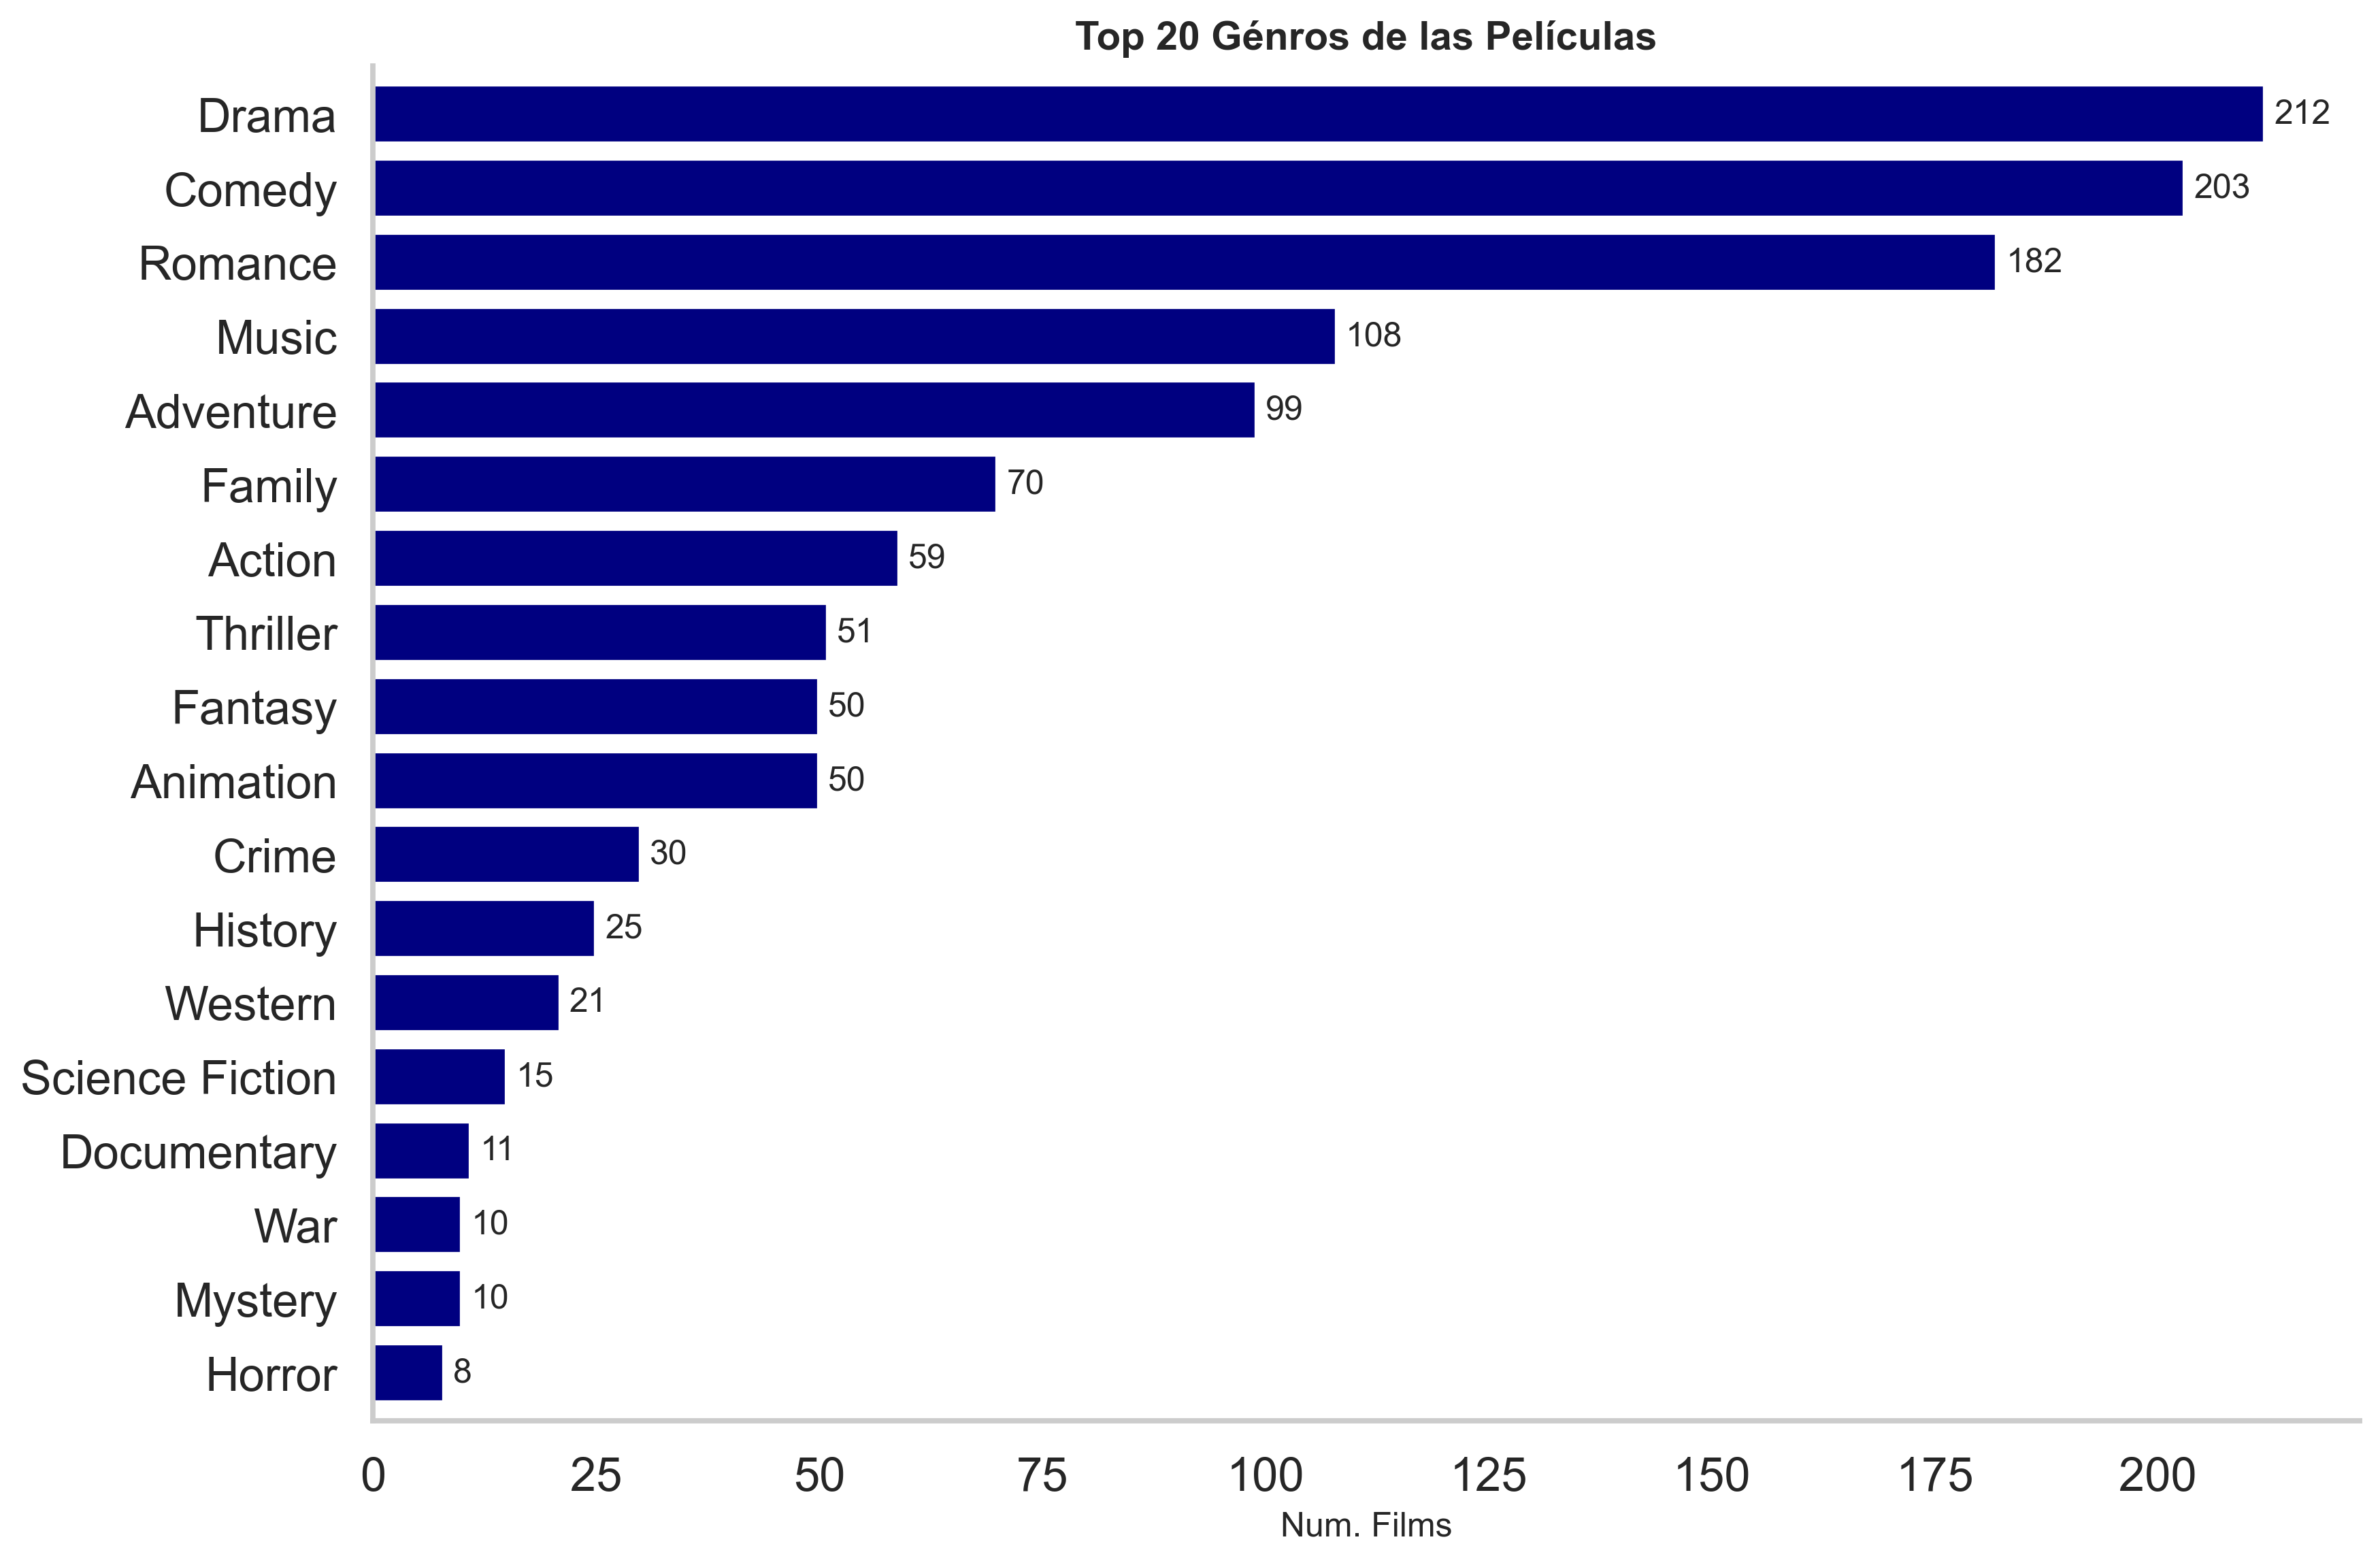

In [ ]:
# Genres Visualization
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# Plot as a horizontal bar chart
top_20_genres.sort_values().plot(
    kind='barh', 
    color='navy', 
    ax=ax,
    width=0.8
)

ax.set_title('Top 20 Génros de las Películas', fontsize=14, weight='bold')
ax.set_xlabel('Num. Films', fontsize=12)
ax.set_ylabel('')  # Leave y-label blank

# Add the counts at the end of each bar
for i, v in enumerate(top_20_genres.sort_values()):
    ax.text(v + 1, i, str(v), va='center', fontsize=12)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.grid(False)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig('plots/films_count_by_genres.png', dpi=300, bbox_inches='tight')
plt.show()

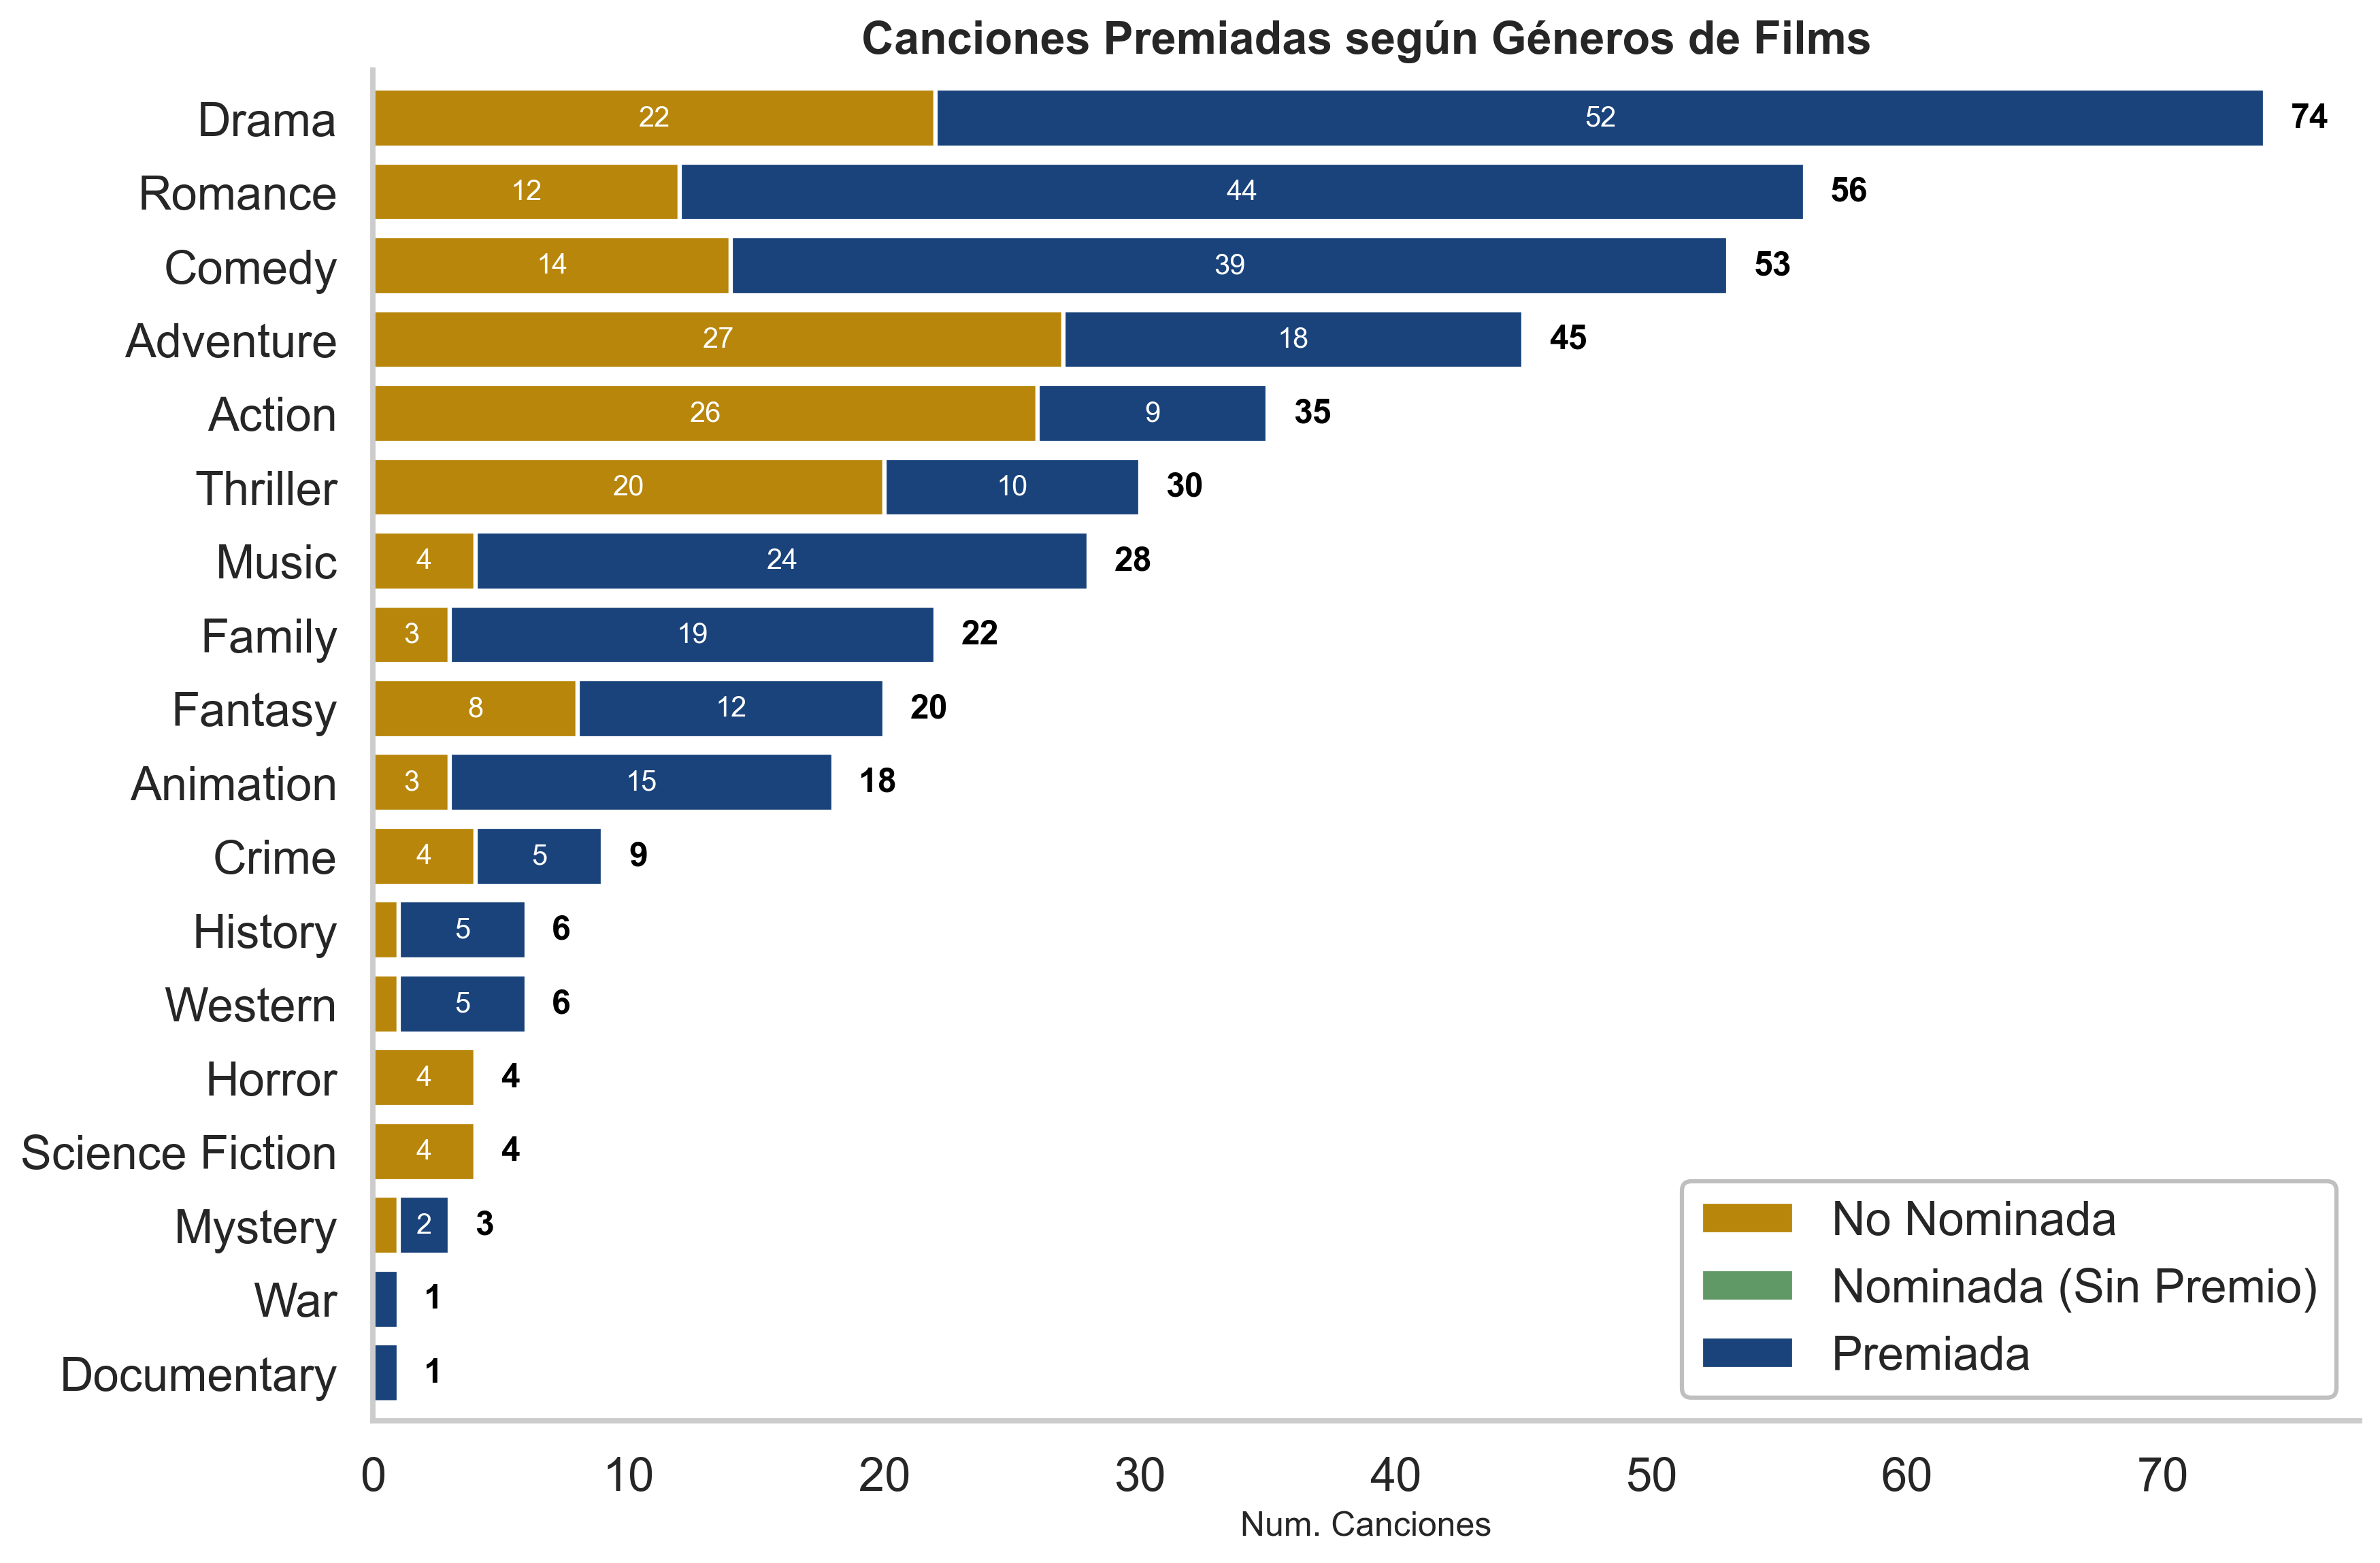

In [ ]:
# MERGE, CLEAN, AND EXPLODE
df_songs_facts = pd.merge(
    df_songs_aux, 
    df_facts_clean[['song_id', 'film_id']], 
    on='song_id', 
    how='left'
)

df_merged = pd.merge(
    df_songs_facts, 
    df_films_aux[['film_id', 'tmdb_genres']], 
    on='film_id', 
    how='left'
)

df_merged['tmdb_genres_clean'] = df_merged['tmdb_genres'].astype(str).str.replace(r"[\[\]'\"]", "", regex=True)

df_exploded = df_merged.assign(genre=df_merged['tmdb_genres_clean'].str.split(',')).explode('genre').reset_index(drop=True)
df_exploded['genre'] = df_exploded['genre'].str.strip()
df_exploded = df_exploded[~df_exploded['genre'].isin(["", "nan", "NaN", "None"])]
df_exploded = df_exploded.dropna(subset=['genre'])

# APPLY AWARD TIERS
conditions = [
    (df_exploded['song_major_awards'] > 0),
    ((df_exploded['oscar_song_nominee'] == True) |
     (df_exploded['grammy_song_nominee'] == True) |
     (df_exploded['grammy_record_nominee'] == True)) & 
    (df_exploded['song_major_awards'] == 0)
]

choices = ['Premiada', 'Nominada (Sin Premio))']
df_exploded['award_tier'] = np.select(conditions, choices, default='No Nominada')

# FILTER TO TOP 20 GENRES AND CROSSTAB
top_20_genres = df_exploded['genre'].value_counts().head(20).index
df_top_20 = df_exploded[df_exploded['genre'].isin(top_20_genres)]

counts_genre = pd.crosstab(df_top_20['genre'], df_top_20['award_tier'])

# Force exact stacking order from left to right
ordered_cols = ['No Nominada', 'Nominada (Sin Premio)', 'Premiada']
for col in ordered_cols:
    if col not in counts_genre.columns:
        counts_genre[col] = 0
counts_genre = counts_genre[ordered_cols]

# Sort the dataframe so the genre with the highest total is plotted at the top
counts_genre['Total'] = counts_genre.sum(axis=1)
counts_genre = counts_genre.sort_values('Total', ascending=True)
counts_genre = counts_genre.drop('Total', axis=1)


# PLOT HORIZONTAL STACKED CHART
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

colors = ['#B8860B', '#609966', '#1A437B']

counts_genre.plot(
    kind='barh', 
    stacked=True, 
    ax=ax, 
    color=colors, 
    width=0.8
)

# ADD LABELS (INNER AND OUTER)
for c in ax.containers:
    labels = [str(int(v.get_width())) if v.get_width() > 1 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='light', fontsize=10)

# Total for each row
totals = counts_genre.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        total + 1,                 # X-coordinate: right of the bar end
        i,                         # Y-coordinate: current bar index
        str(int(total)),           # Text to display
        va='center',               # Vertically align to the middle of the bar
        ha='left',                 # Horizontally align so text flows to the right
        fontsize=12, 
        weight='bold', 
        color='black'
    )

# PRESENTATION
ax.set_title('Canciones Premiadas según Géneros de Films', fontsize=16, weight='bold')
ax.set_xlabel('Num. Canciones', fontsize=12)
ax.set_ylabel('') # Leave y-label blank since the genres speak for themselves

plt.legend(
    # title='Award Status', 
    loc='lower right', 
    frameon=True,
    facecolor='white',
    framealpha=0.5,
    edgecolor='gray'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig('plots/songs_awards_by_film_genre.png', dpi=300, bbox_inches='tight')
plt.show()

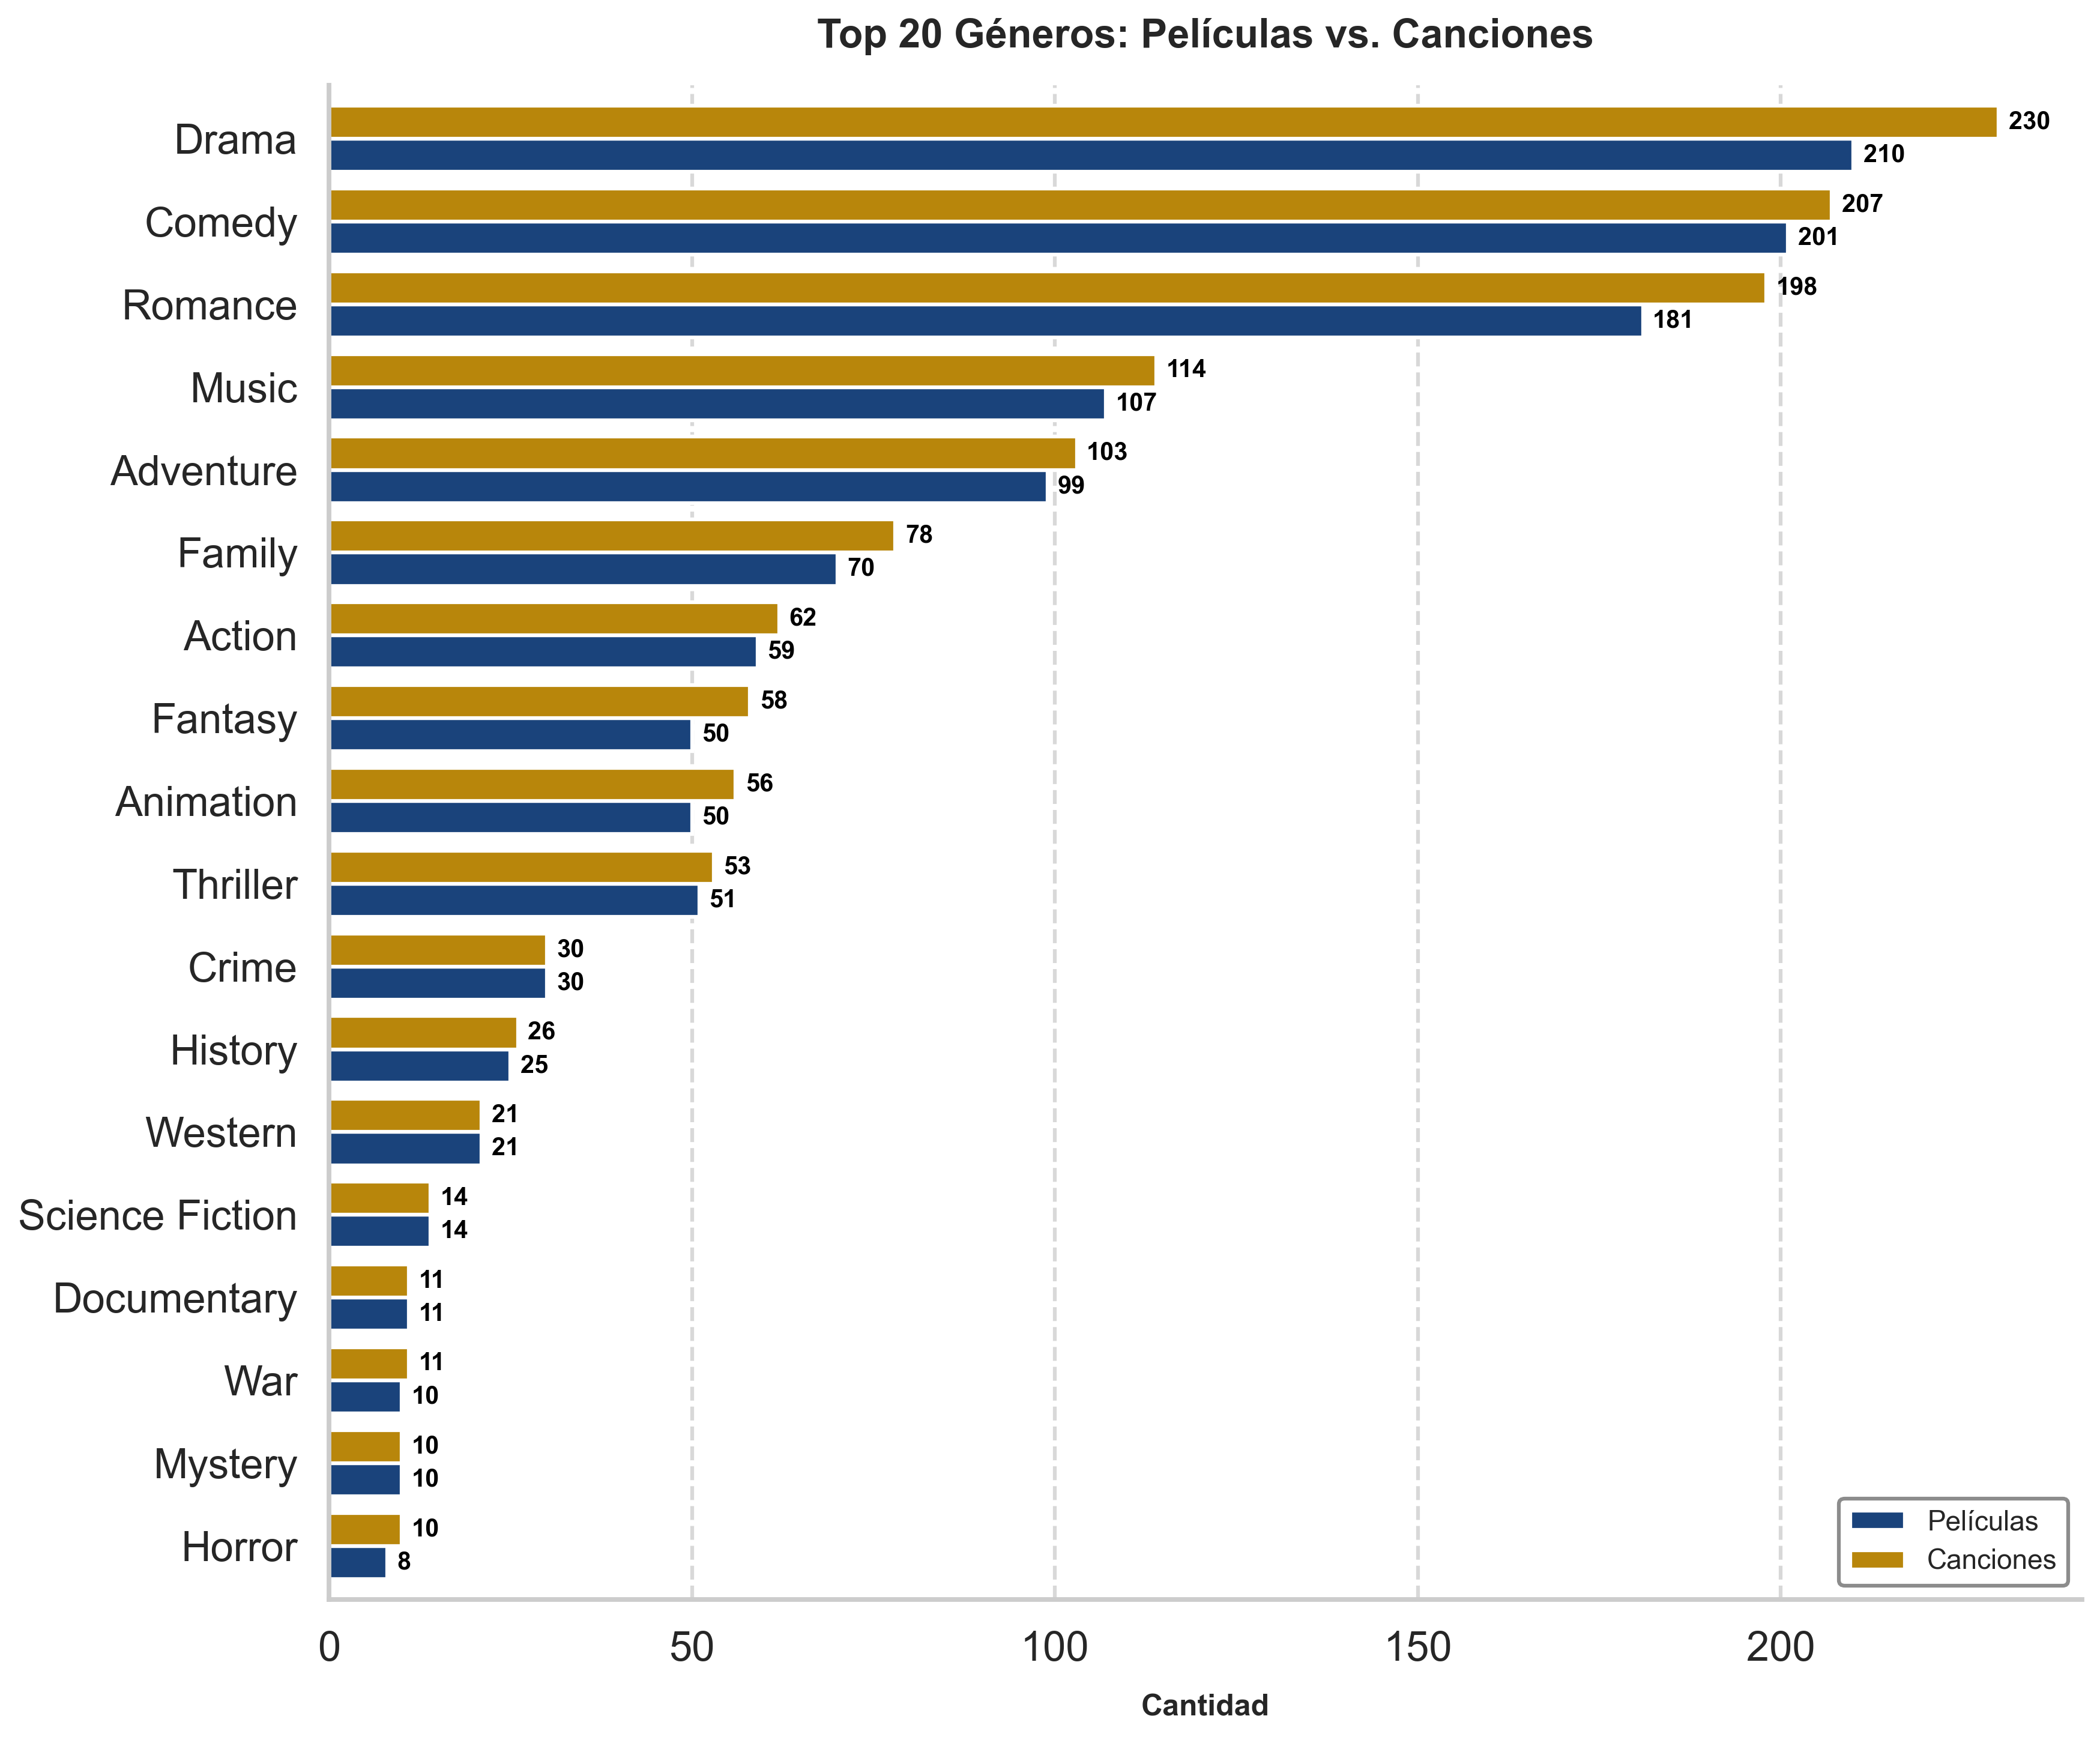

In [ ]:
# Films and Songs by Film Genres

# MERGE, CLEAN, AND EXPLODE
df_songs_facts = pd.merge(
    df_songs_aux, 
    df_facts_clean[['song_id', 'film_id']], 
    on='song_id', 
    how='left'
)

df_merged = pd.merge(
    df_songs_facts, 
    df_films_aux[['film_id', 'tmdb_genres']], 
    on='film_id', 
    how='left'
)

df_merged['tmdb_genres_clean'] = df_merged['tmdb_genres'].astype(str).str.replace(r"[\[\]'\"]", "", regex=True)
df_exploded = df_merged.assign(genre=df_merged['tmdb_genres_clean'].str.split(',')).explode('genre').reset_index(drop=True)
df_exploded['genre'] = df_exploded['genre'].str.strip()
df_exploded = df_exploded[~df_exploded['genre'].isin(["", "nan", "NaN", "None"])]
df_exploded = df_exploded.dropna(subset=['genre'])

# GROUP AND CALCULATE UNIQUE COUNTS
genre_counts = df_exploded.groupby('genre').agg(
    film_count=('film_id', 'nunique'),
    song_count=('song_id', 'nunique')
)

# Rename the columns
genre_counts = genre_counts.rename(columns={
    'film_count': 'Películas', 
    'song_count': 'Canciones'
})

genre_counts = genre_counts.sort_values(by='Canciones', ascending=False).head(20)
# Reverse the order (ascending=True) so the largest appears at the top of the horizontal chart
genre_counts = genre_counts.sort_values(by='Canciones', ascending=True)

# PLOT THE GROUPED DOUBLE-BAR CHART
fig, ax = plt.subplots(figsize=(12, 10), dpi=300) # Slightly taller to accommodate double bars

genre_counts.plot(
    kind='barh', 
    stacked=False, 
    ax=ax, 
    color=['#1A437B', '#B8860B'], 
    width=0.8
)

# LABELS AND PRESENTATION
for c in ax.containers:
    ax.bar_label(c, padding=4, fontsize=10, weight='bold', color='black')

ax.set_title('Top 20 Géneros: Películas vs. Canciones', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Cantidad', fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel('') # Leave y-label blank since the genres speak for themselves

plt.legend(
    title='', 
    loc='lower right', 
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    edgecolor='gray',
    fontsize=11
)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a soft vertical grid line
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle='--', color='gray', alpha=0.3)
ax.yaxis.grid(False) # Turn off horizontal grid lines to keep it clean

plt.tight_layout()
plt.savefig('plots/films_vs_songs_by_genre.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribución de Streams Spotify

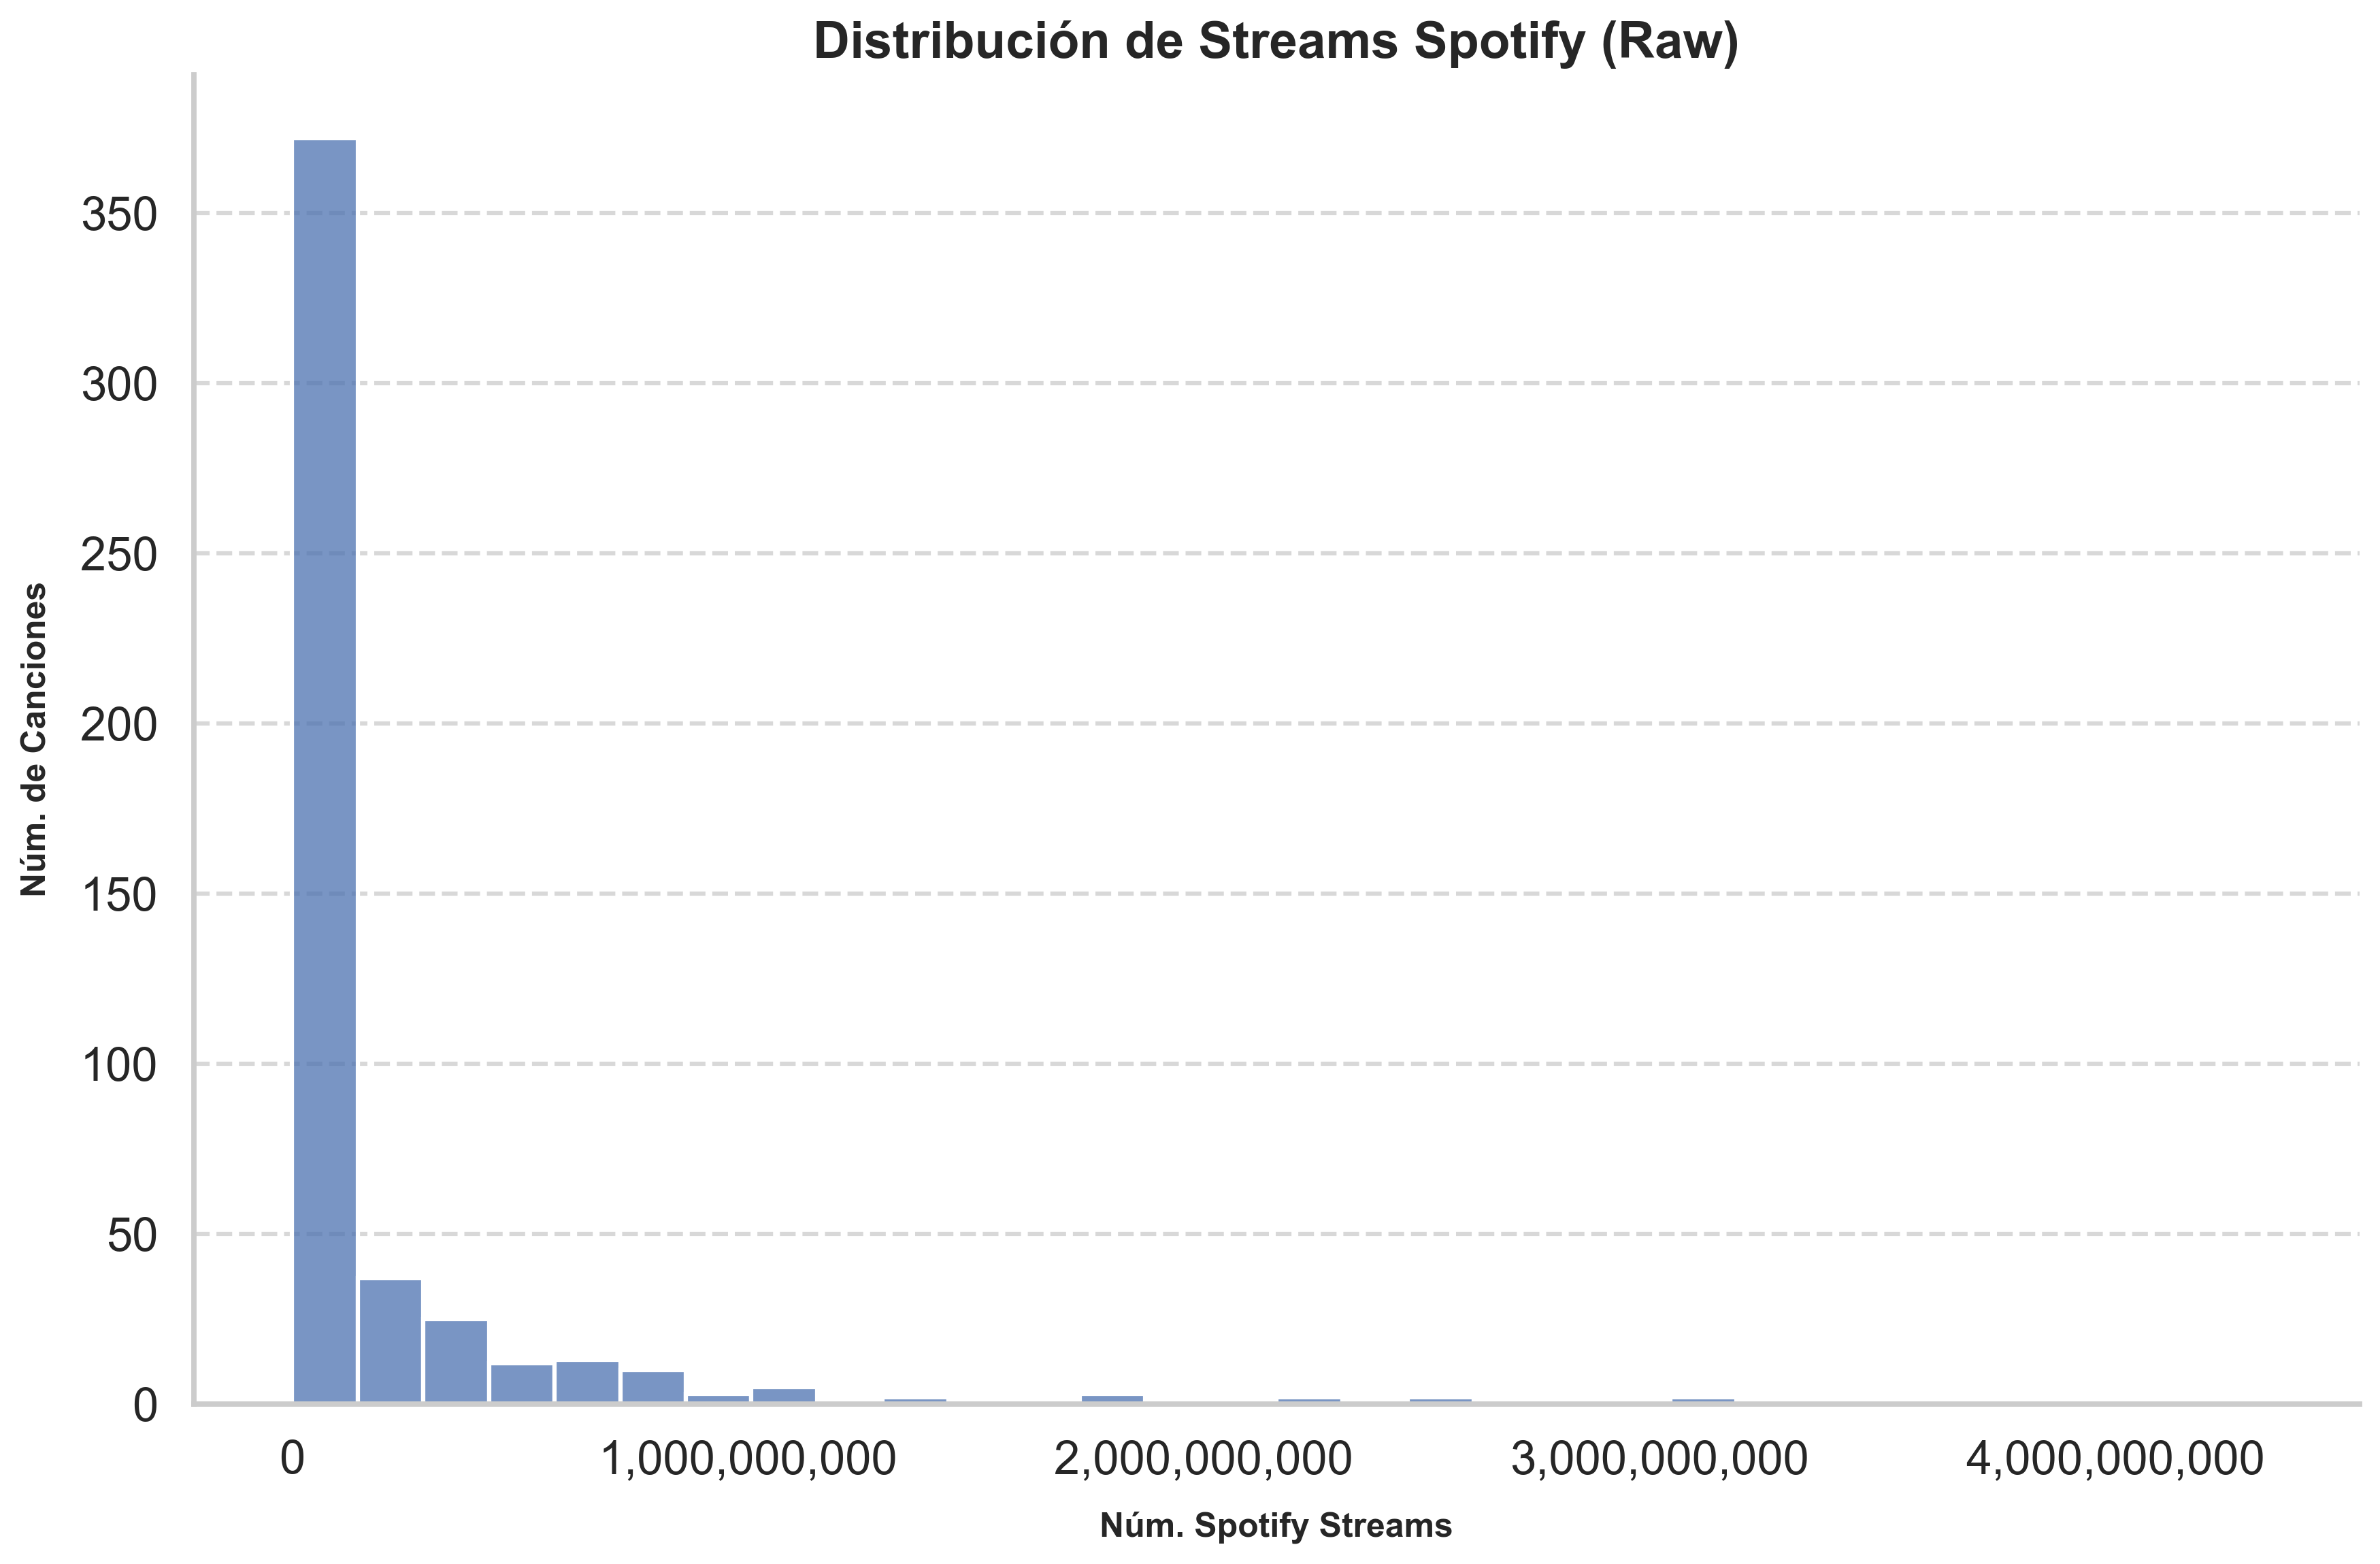

In [ ]:
# Streams Raw
plt.figure(figsize=(12, 8), dpi=300)
ax = sns.histplot(data=df_songs_aux, x='streams_obs_max', bins=30)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel('Núm. Spotify Streams', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. de Canciones', fontsize=12, fontweight='bold', labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)

plt.title('Distribución de Streams Spotify (Raw)')
plt.tight_layout()

plt.savefig('plots/songs_streams_raw.png', dpi=300, bbox_inches='tight')
plt.show()

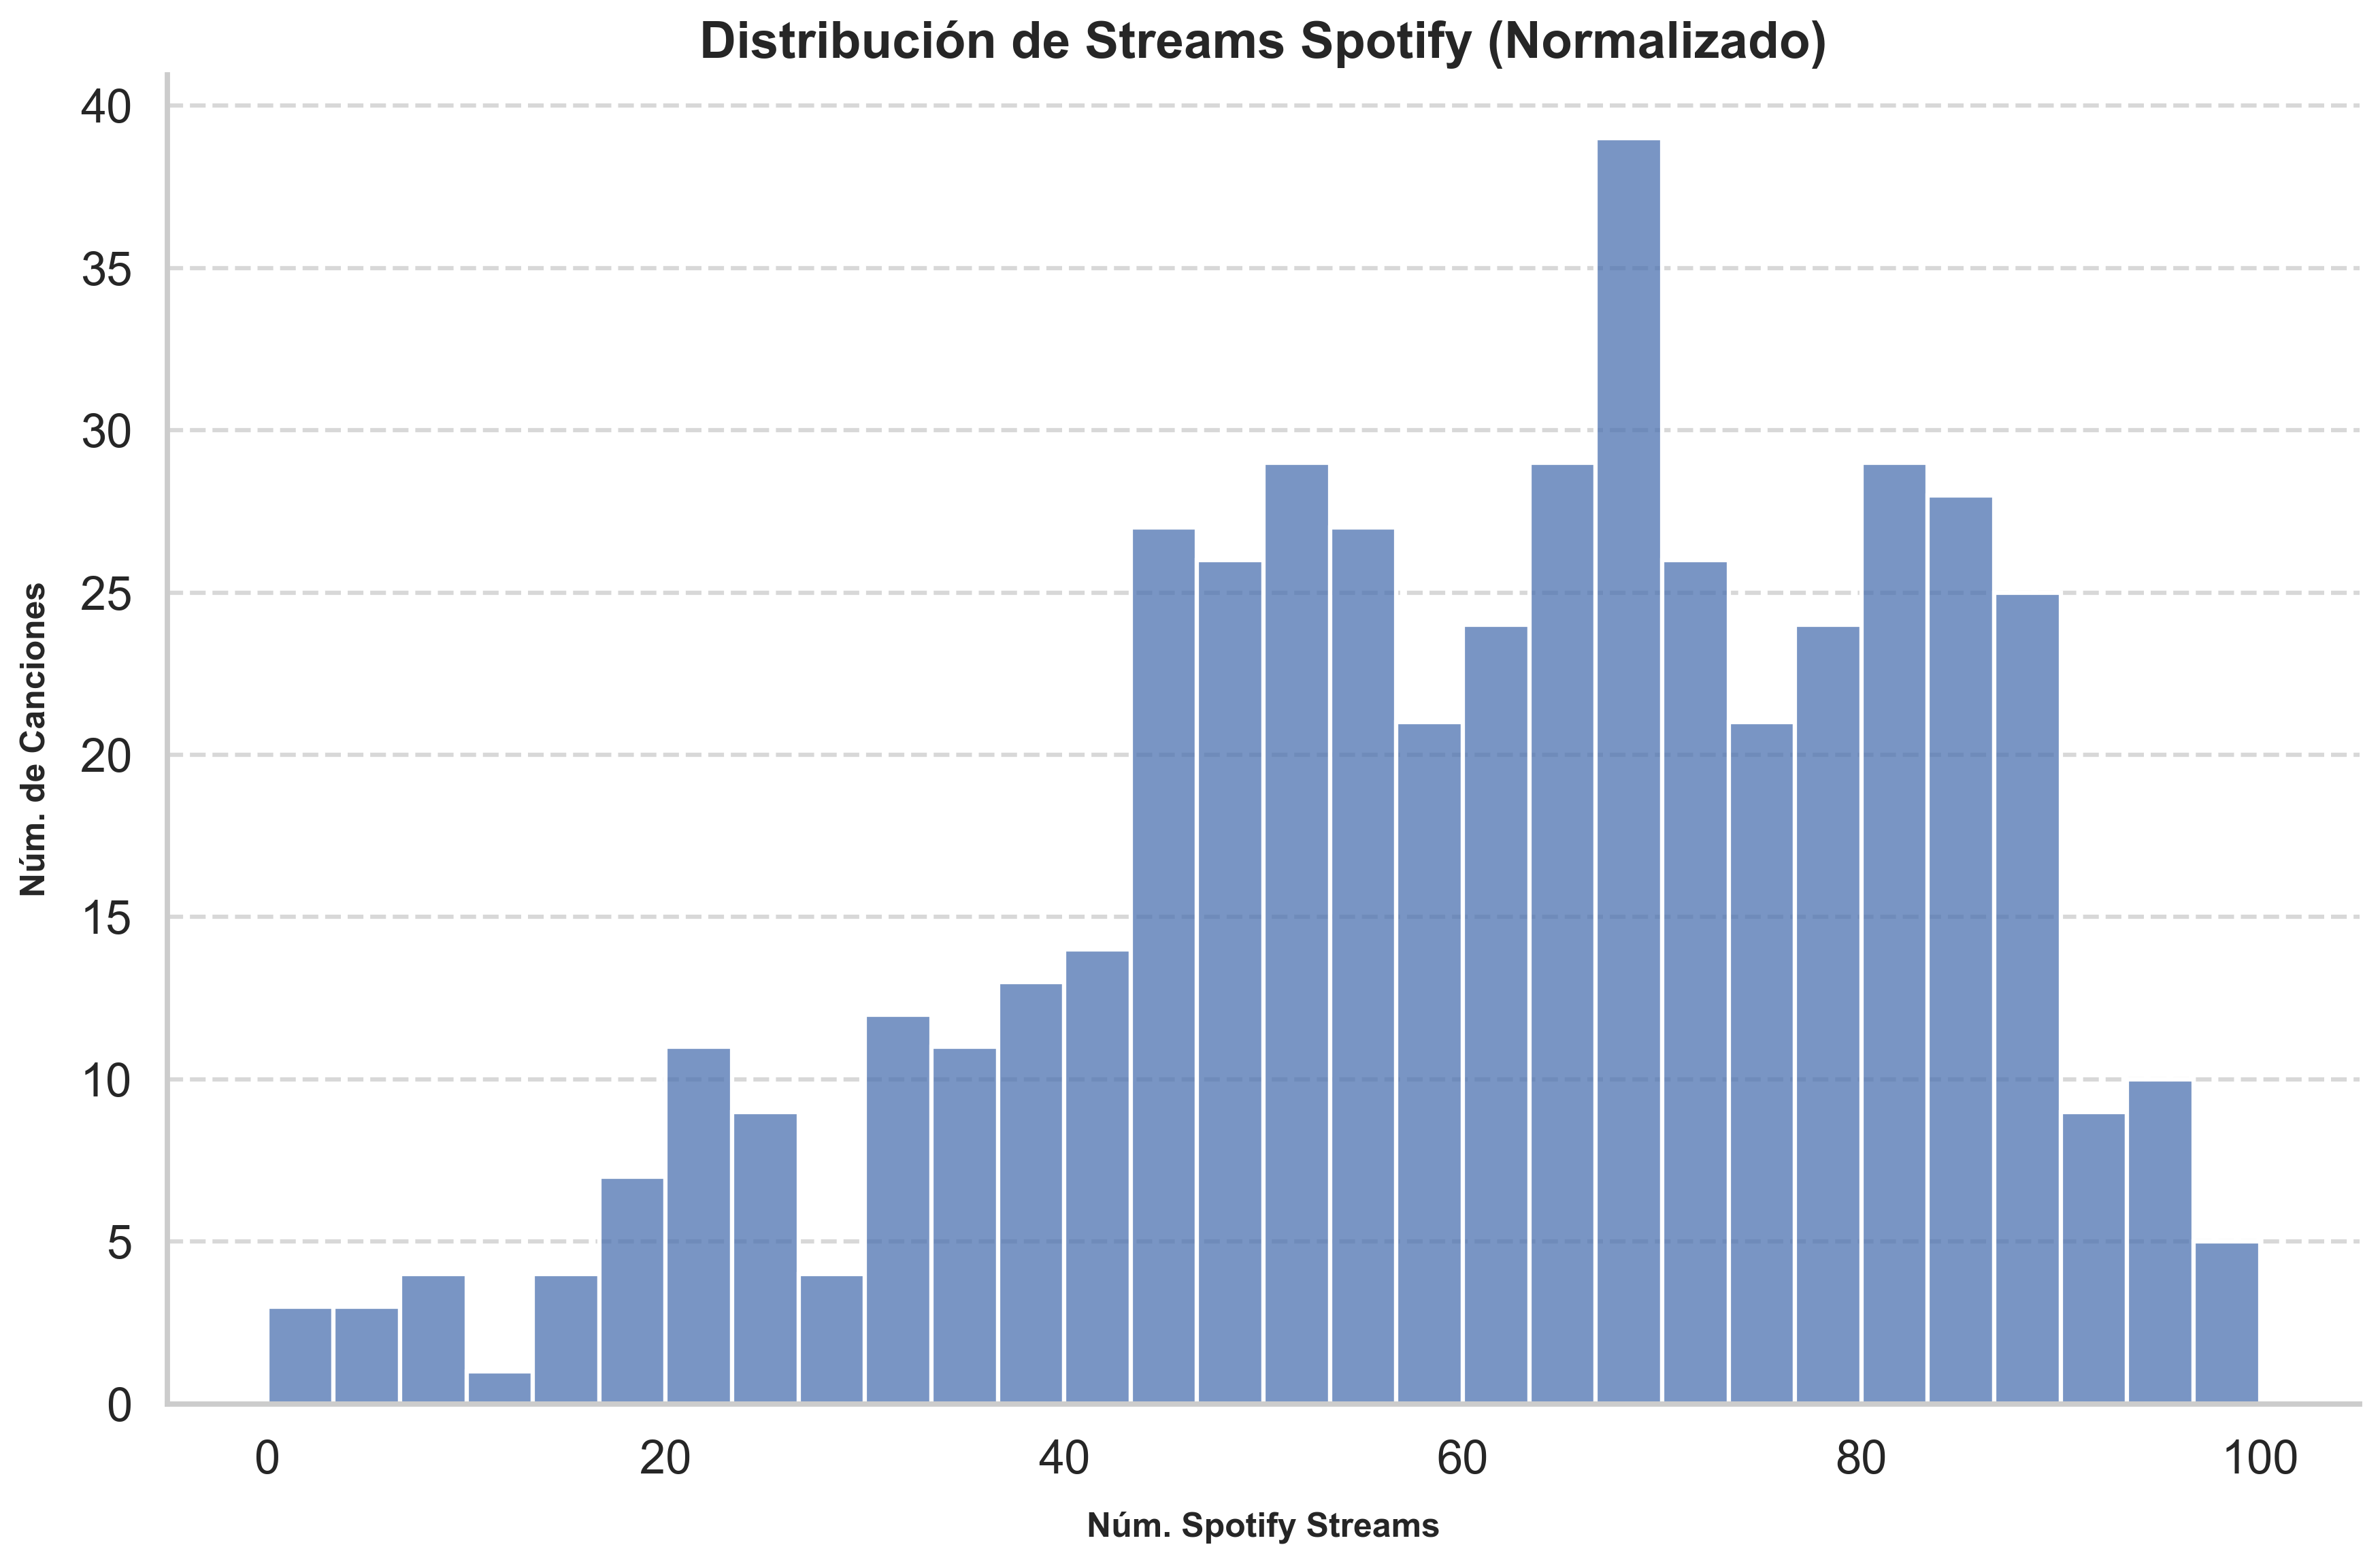

In [ ]:
# Streams Normalized
plt.figure(figsize=(12, 8), dpi=300)
ax = sns.histplot(data=df_songs_aux, x='streams_normalized', bins=30)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel('Núm. Spotify Streams', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. de Canciones', fontsize=12, fontweight='bold', labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)

plt.title('Distribución de Streams Spotify (Normalizado)')
plt.tight_layout()

plt.savefig('plots/songs_streams_norm.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribución de Films Revenue

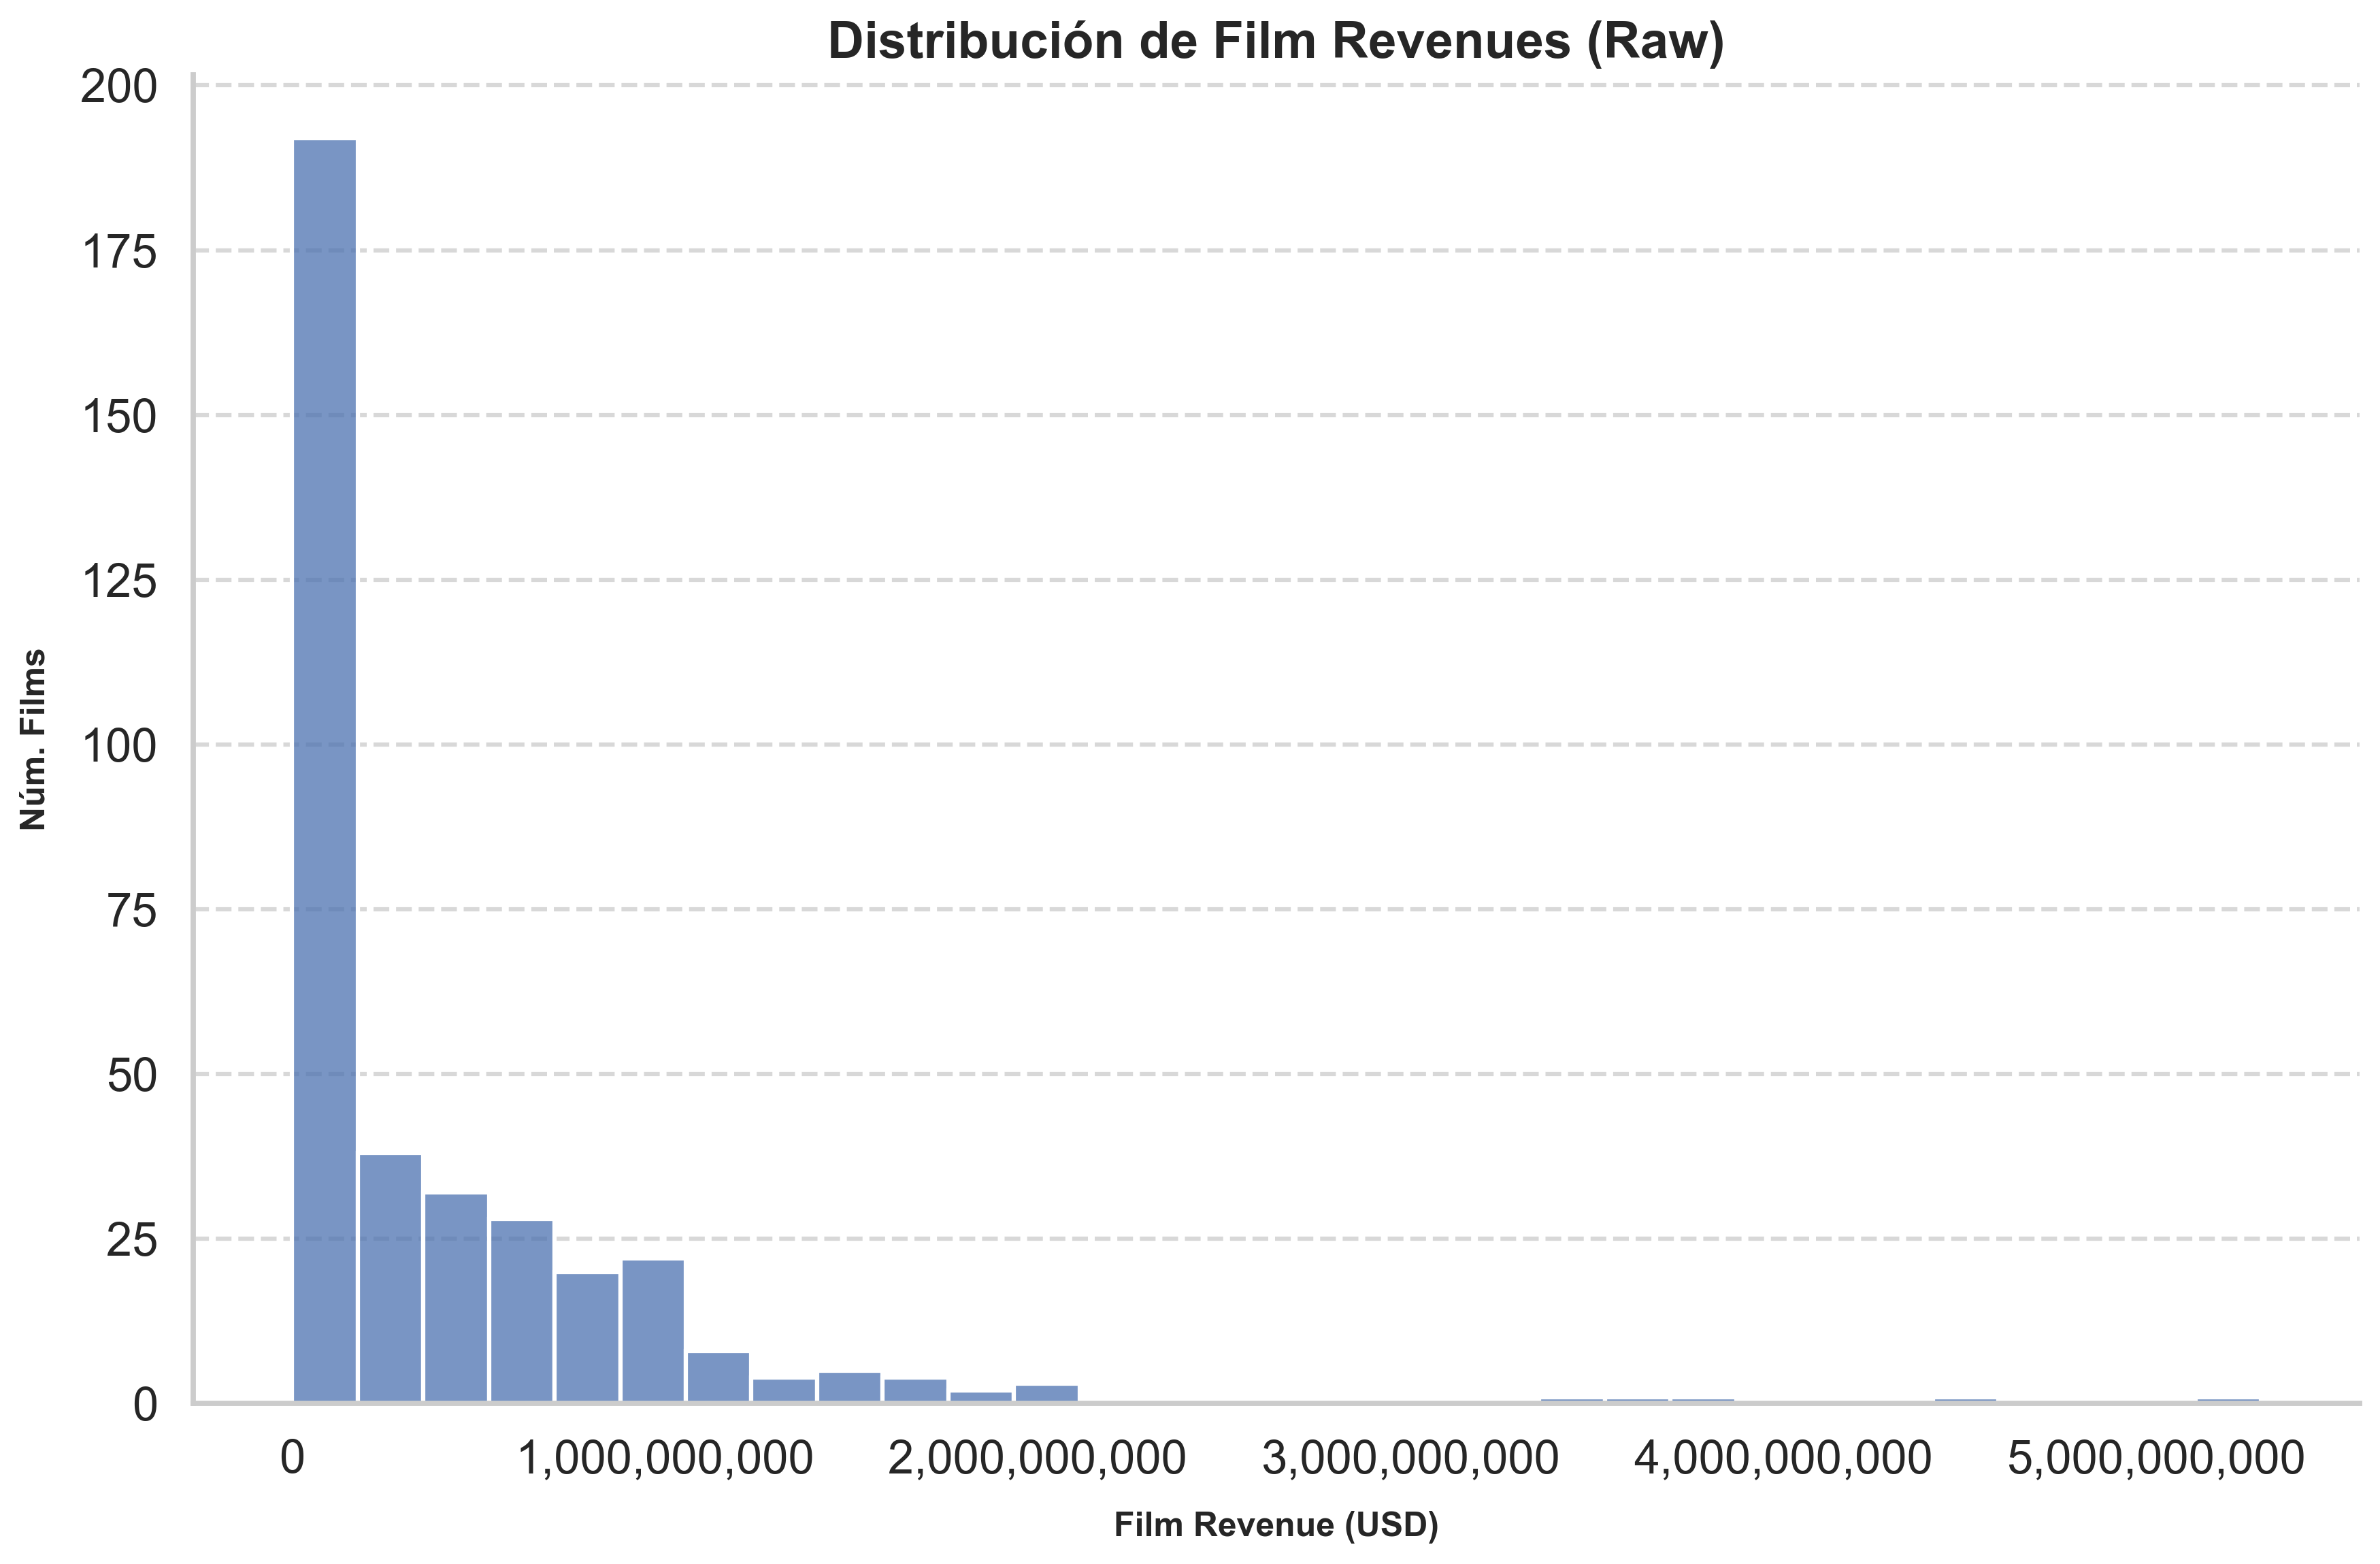

In [ ]:
# Revenues Raw
plt.figure(figsize=(12, 8), dpi=300)
ax = sns.histplot(data=df_films_aux, x='revenue_adjusted', bins=30)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel('Film Revenue (USD)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. Films', fontsize=12, fontweight='bold', labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)

plt.title('Distribución de Film Revenues (Raw)')
plt.tight_layout()

plt.savefig('plots/films_revenues_raw.png', dpi=300, bbox_inches='tight')
plt.show()

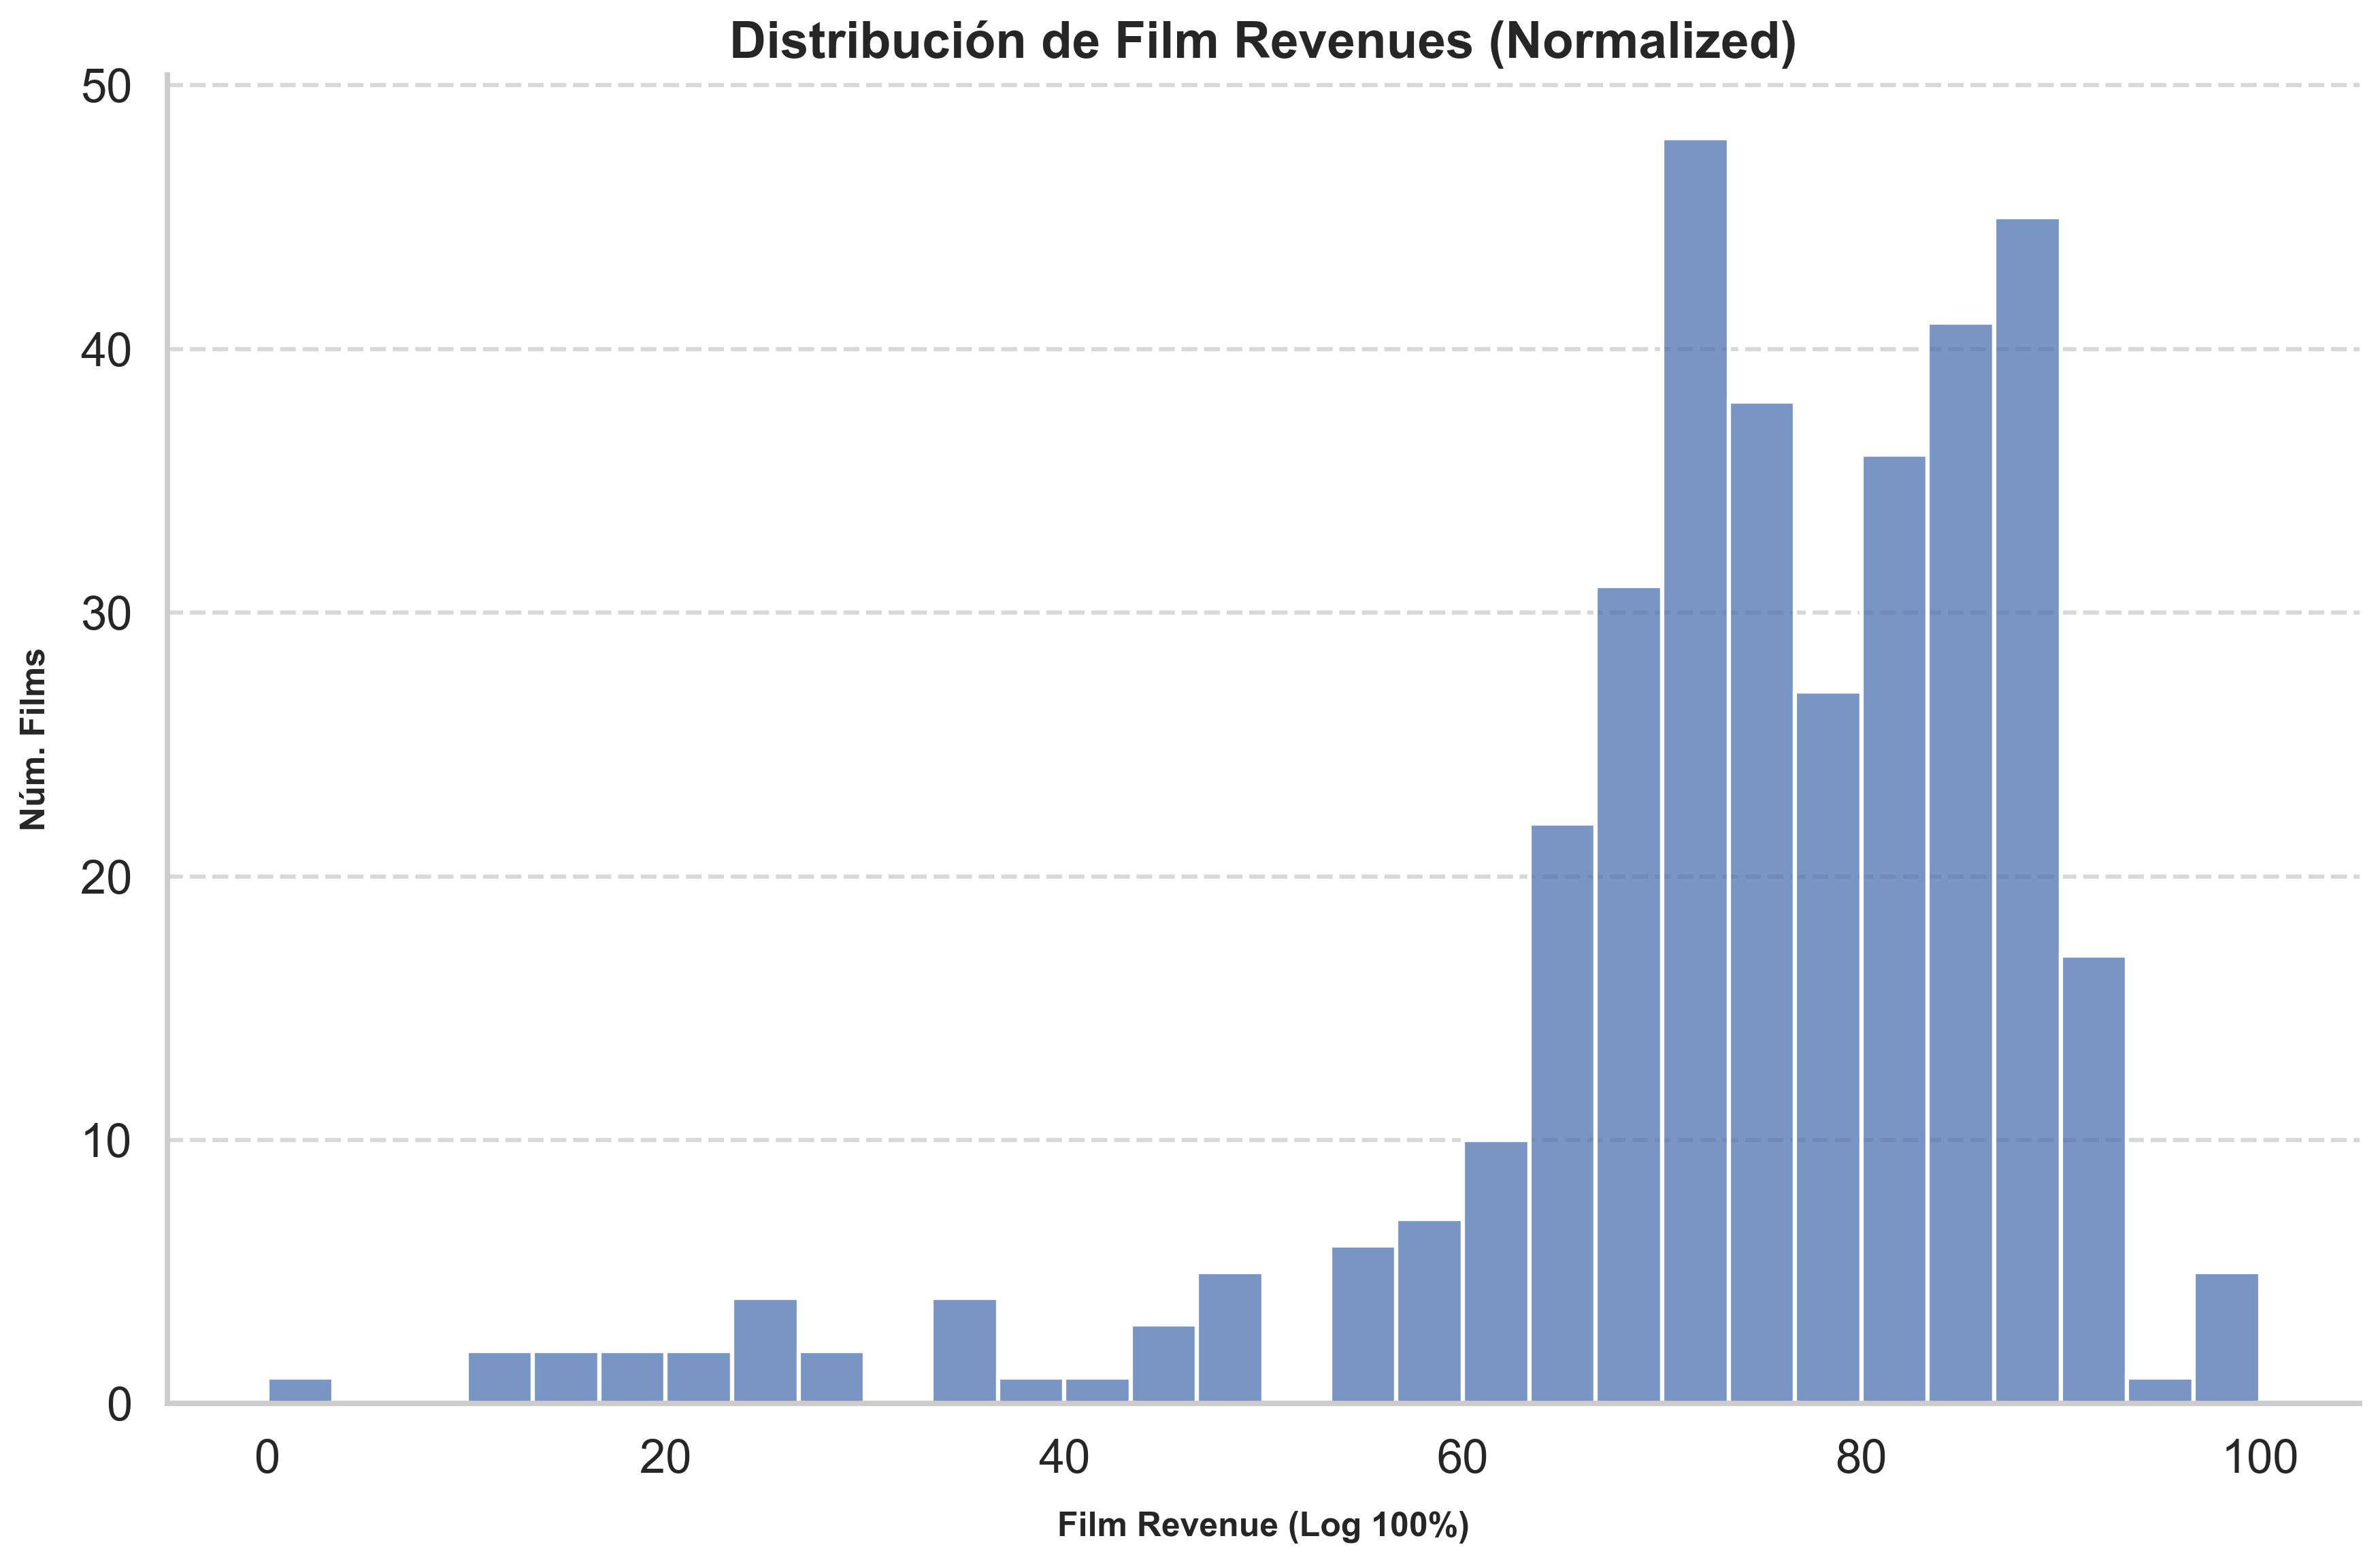

In [ ]:
# Revenues Normalized
plt.figure(figsize=(12, 8), dpi=300)
ax = sns.histplot(data=df_films_aux, x='revenue_adjusted_normalized', bins=30)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel('Film Revenue (Log 100%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Núm. Films', fontsize=12, fontweight='bold', labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.3)
ax.xaxis.grid(False)

plt.title('Distribución de Film Revenues (Normalized)')
plt.tight_layout()

plt.savefig('plots/films_revenues_norm.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribución Film Revenue por Década

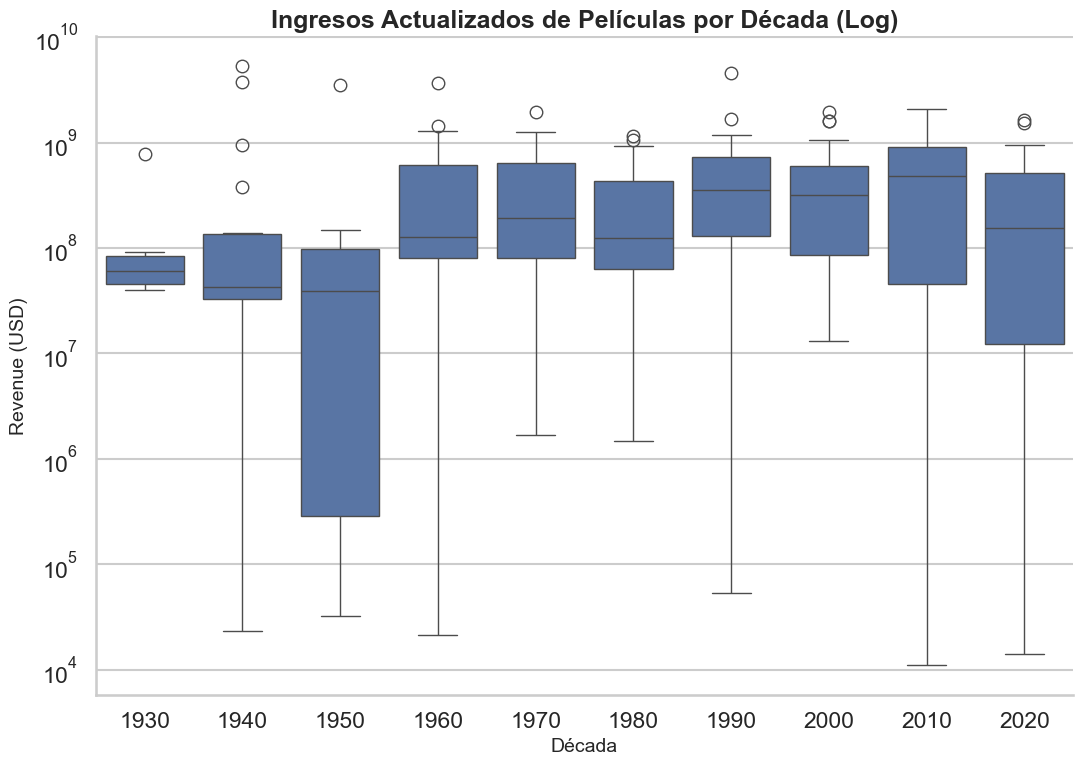

In [ ]:
# Films Revenues by Decade

df_films_aux_decades = df_films_aux.sort_values(by='decade')

plt.figure(figsize=(12, 8))

# Filter out the unreliable film revenues
df_clean_revenues = df_films_aux_decades[df_films_aux_decades['revenue_adjusted'] > 10000]

sns.boxplot(
    data=df_clean_revenues, 
    x='decade', 
    y='revenue_adjusted', 
)

plt.title('Ingresos Actualizados de Películas por Década (Log)')
plt.xlabel('Década')
plt.ylabel('Revenue (USD)') # Fixed the label!

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.yscale('log')

plt.savefig('plots/revenue_distribution_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()


## CORRELACIONES

### Merge Canciones y Films

In [ ]:
# Merge Films and Songs

songs_films_junction = df_facts_clean[['song_id', 'film_id']].drop_duplicates()

# Merge Songs and Films with the junction table
df_temp = df_songs_clean.merge(songs_films_junction, on='song_id', how='inner')

df_songs_films_merged = df_temp.merge(
    df_films_clean, 
    on='film_id', 
    how='inner', 
    suffixes=('_song', '_film')
)

print(f"Original songs: {len(df_songs_clean)}")
print(f"Original films: {len(df_films_clean)}")
print(f"Merged analysis dataframe shape: {df_songs_films_merged.shape}")

target_cols = [
    'song_title', 'film_title', 
    'streams_obs_max', 'lastfm_track_listeners', 
    'budget_adjusted', 'revenue_adjusted', 'commercial_success_factor'
]
display(df_songs_films_merged[target_cols].head())

Original songs: 497
Original films: 467
Merged analysis dataframe shape: (497, 112)


,song_title,film_title,streams_obs_max,lastfm_track_listeners,budget_adjusted,revenue_adjusted,commercial_success_factor
0,The Continental,The Gay Divorcee,65000,9785,12493310,43246075,1.38
1,Love In Bloom,She Loves Me Not,171500,2456,<NA>,<NA>,NaN
2,Lullaby Of Broadway,Gold Diggers of 1935,7020000,20474,<NA>,<NA>,NaN
3,Cheek To Cheek,Top Hat,210100000,466316,14311189,75245364,2.10
4,Lovely To Look At,Roberta,218000,1389,<NA>,<NA>,NaN


### Filtrar Dataset para Análisis de Films

In [10]:
# Select valid Budgets and Revenues
missing_budget = df_songs_films_merged['budget_adjusted'].isna() | (df_songs_films_merged['budget_adjusted'] < 10000)
missing_revenue = df_songs_films_merged['revenue_adjusted'].isna() | (df_songs_films_merged['revenue_adjusted'] < 10000)

df_songs_films_analysis = df_songs_films_merged[~(missing_budget & missing_revenue)].copy()

rows_dropped = len(df_songs_films_merged) - len(df_songs_films_analysis)
print(f"Original rows: {len(df_songs_films_merged)}")
print(f"Rows with usable financial data: {len(df_songs_films_analysis)}")
print(f"Dropped {rows_dropped} rows where both budget and revenue were null/0.")

Original rows: 497
Rows with usable financial data: 426
Dropped 71 rows where both budget and revenue were null/0.


### Correlación Presupuestos Films vs. Streams

In [11]:
# Correlation Budget vs. Streams
valid_budgets = df_songs_films_analysis[(df_songs_films_analysis['budget_adjusted'] >= 10000)]

pearson = valid_budgets['budget_adjusted'].corr(valid_budgets['streams_obs_max'], method='pearson')
spearman = valid_budgets['budget_adjusted'].corr(valid_budgets['streams_obs_max'], method='spearman')

print(f"Pearson Correlation: {pearson:.3f}")
print(f"Spearman Correlation: {spearman:.3f}")

Pearson Correlation: 0.196
Spearman Correlation: 0.226


### Correlación Ingresos Films vs. Streams Canciones

In [12]:
# Correlation Revenue vs. Streams
valid_revenues = df_songs_films_analysis[(df_songs_films_analysis['revenue_adjusted'] >= 10000)]

pearson_rev = valid_revenues['revenue_adjusted'].corr(valid_revenues['streams_obs_max'], method='pearson')
spearman_rev = valid_revenues['revenue_adjusted'].corr(valid_revenues['streams_obs_max'], method='spearman')

print(f"Pearson Correlation (Revenue): {pearson_rev:.3f}")
print(f"Spearman Correlation (Revenue): {spearman_rev:.3f}")

Pearson Correlation (Revenue): 0.239
Spearman Correlation (Revenue): 0.472


### Correlación Balance Comercial Films vs. Streams

In [13]:
# Correlation Commercial balance vs. Streams
strict_financials = df_songs_films_merged[
    (df_songs_films_merged['budget_adjusted'] >= 10000) & 
    (df_songs_films_merged['revenue_adjusted'] >= 10000)
].copy()

pearson_csf = strict_financials['commercial_success_factor_normalized'].corr(
    strict_financials['streams_normalized'], method='pearson'
)
spearman_csf = strict_financials['commercial_success_factor_normalized'].corr(
    strict_financials['streams_normalized'], method='spearman'
)

print(f"Valid rows after strict filtering: {len(strict_financials)}")
print(f"Pearson Correlation (Commercial Success vs Streams): {pearson_csf:.3f}")
print(f"Spearman Correlation (Commercial Success vs Streams): {spearman_csf:.3f}")

Valid rows after strict filtering: 350
Pearson Correlation (Commercial Success vs Streams): 0.317
Spearman Correlation (Commercial Success vs Streams): 0.394


### Correlación Ingresos Films vs. LastFM

In [14]:
# Correlation Revenue vs. LastFM Playcounts
pearson_norm = valid_revenues['revenue_adjusted_normalized'].corr(valid_revenues['lastfm_track_playcount_normalized'], method='pearson')
spearman_norm = valid_revenues['revenue_adjusted_normalized'].corr(valid_revenues['lastfm_track_playcount_normalized'], method='spearman')

print(f"Pearson Correlation (Normalized): {pearson_norm:.3f}")
print(f"Spearman Correlation (Normalized): {spearman_norm:.3f}")

Pearson Correlation (Normalized): 0.320
Spearman Correlation (Normalized): 0.398


### Correlación Streams vs. Nominaciones Films

In [15]:
# Correlation Nominations vs. Streams
pearson_cult = df_songs_films_merged['total_nominations'].corr(df_songs_films_merged['streams_normalized'], method='pearson')
spearman_cult = df_songs_films_merged['total_nominations'].corr(df_songs_films_merged['streams_normalized'], method='spearman')

print(f"Pearson (Revenue vs Cultural Footprint): {pearson_cult:.3f}")
print(f"Spearman (Revenue vs Cultural Footprint): {spearman_cult:.3f}")

Pearson (Revenue vs Cultural Footprint): 0.199
Spearman (Revenue vs Cultural Footprint): 0.367


### Streams vs. Films Revenue

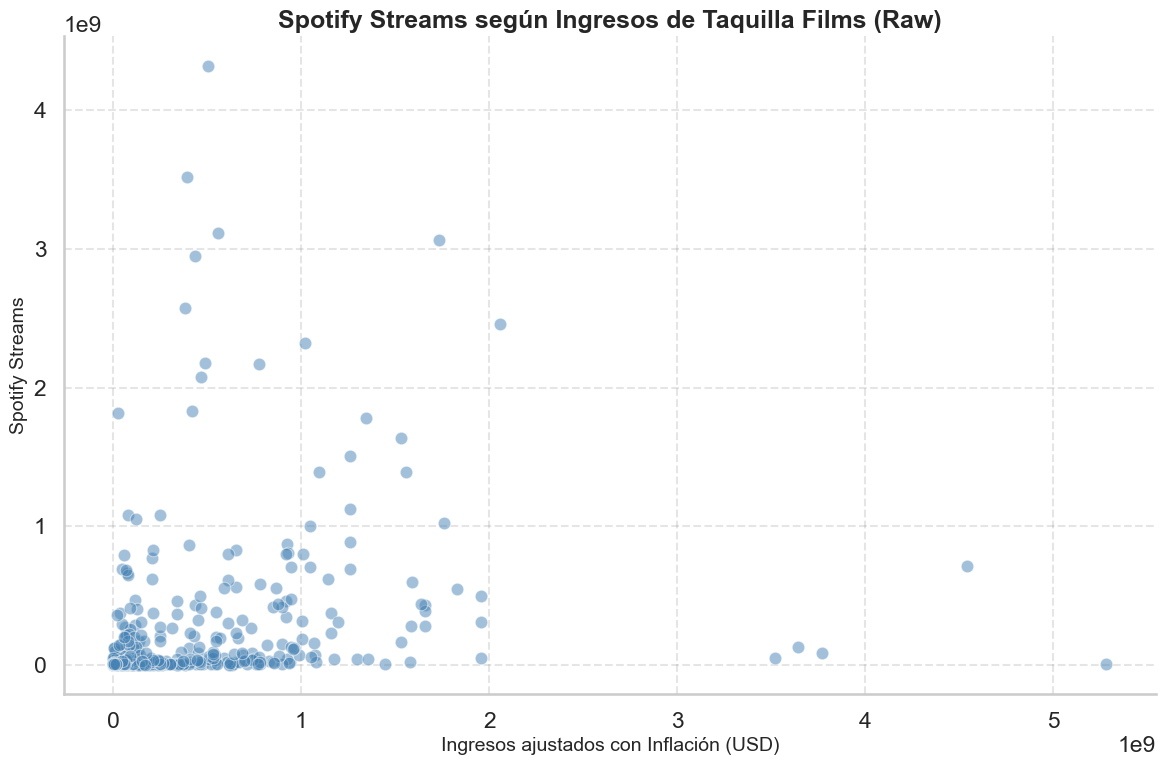

In [ ]:
# Plot Revenues vs. Streams (Raw)

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=valid_revenues, 
    x='revenue_adjusted', 
    y='streams_obs_max', 
    alpha=0.5,
    color='steelblue',
    ax=ax
)

# ax.set_xscale('log')
# ax.set_yscale('log')

plt.title('Spotify Streams según Ingresos de Taquilla Films (Raw)')
plt.xlabel('Ingresos ajustados con Inflación (USD)')
plt.ylabel('Spotify Streams')

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.2)
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.2)
# ax.xaxis.grid(False)

plt.savefig('plots/revenue_vs_streams_raw.png', dpi=300, bbox_inches='tight')
plt.show()

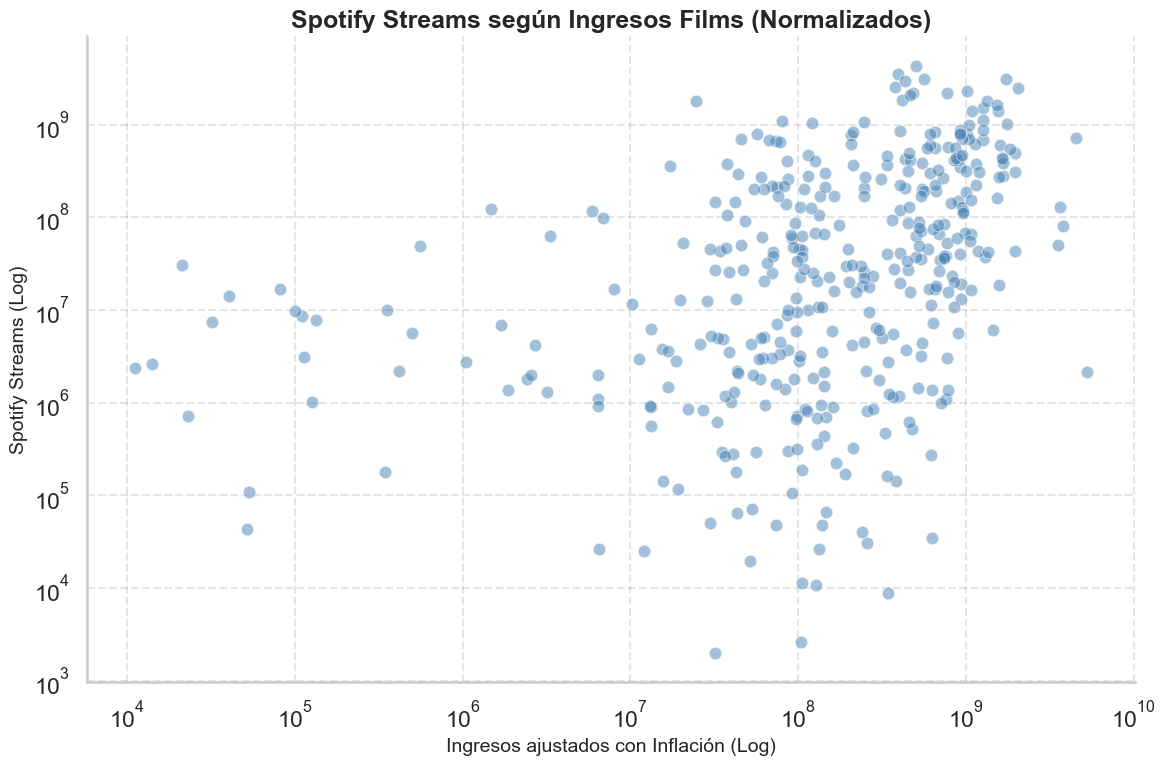

In [ ]:
# Plot Revenues vs. Streams (Logarithmic)

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=valid_revenues, 
    x='revenue_adjusted', 
    y='streams_obs_max', 
    alpha=0.5,
    color='steelblue',
    ax=ax
)

ax.set_xscale('log')
ax.set_yscale('log')

plt.title('Spotify Streams según Ingresos Films (Normalizados)')
plt.xlabel('Ingresos ajustados con Inflación (Log)')
plt.ylabel('Spotify Streams (Log)')

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.2)
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.2)
# ax.xaxis.grid(False)

plt.savefig('plots/revenue_vs_streams_norm.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualización Final

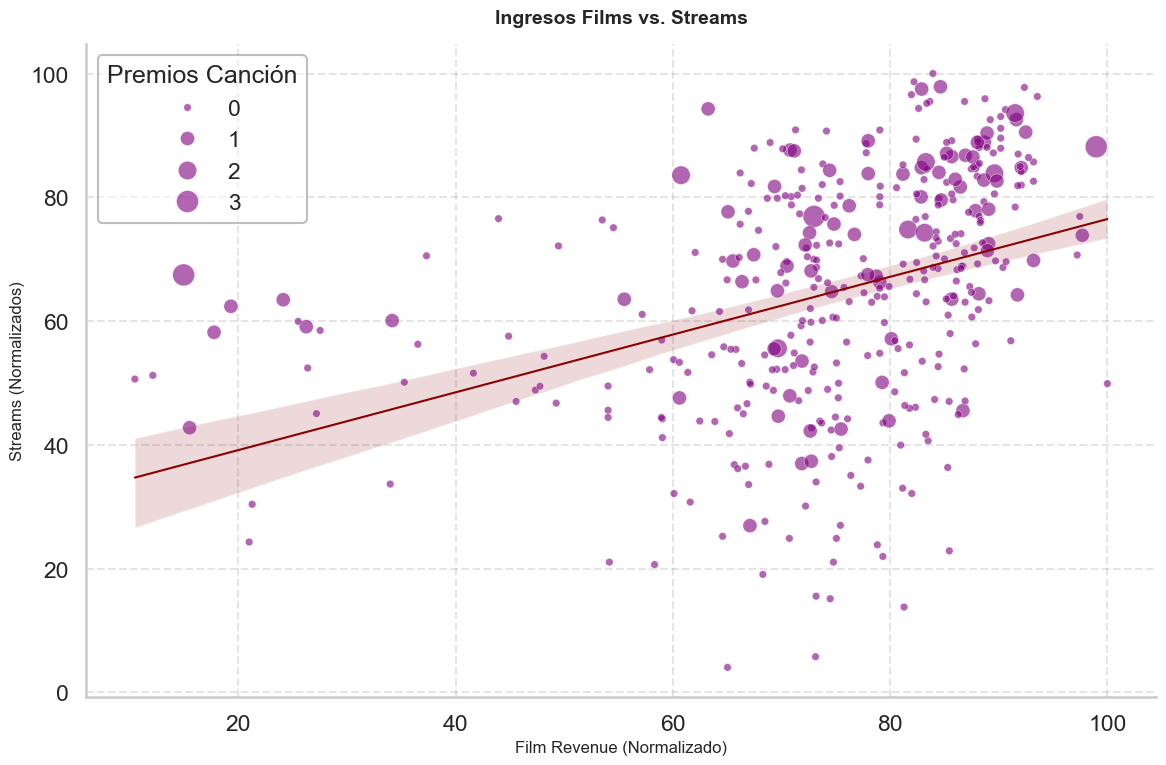

In [ ]:
# Plot Revenues vs. Streams (Normalized)

fig, ax = plt.subplots(figsize=(12, 8))

# Regression line
sns.regplot(
    data=valid_revenues, 
    x='revenue_adjusted_normalized', 
    y='streams_normalized', 
    scatter=False, 
    line_kws={'color': 'darkred', 'linewidth': 1.5},
    ax=ax
)

# Variable-sized scatter points on top
sns.scatterplot(
    data=valid_revenues,
    x='revenue_adjusted_normalized',
    y='streams_normalized',
    size='song_major_awards', 
    sizes=(30, 250),          # 0 awards = size 30, 3 awards = size 250
    alpha=0.6,                # Keeps overlapping bubbles visible
    color='purple',
    edgecolor='white',        # Adds a crisp border to make the bubbles pop
    ax=ax
)

# Labels and layout
plt.title('Ingresos Films vs. Streams', fontsize=14, pad=15)
plt.xlabel('Film Revenue (Normalizado)', fontsize=12)
plt.ylabel('Streams (Normalizados)', fontsize=12)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.2)
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.2)

plt.legend(
    title='Premios Canción', 
    loc='upper left', 
    frameon=True,
    facecolor='white',
    framealpha=0.5,
    edgecolor='gray'
)

plt.tight_layout() 
plt.savefig('plots/revenue_vs_streams_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Song values examples

# print(df_songs_films_merged[df_songs_films_merged['song_id'] == 198501][['song_title', 'film_title', 'revenue_adjusted_normalized', 'streams_normalized']].to_string())

top_3_songs_streams = df_songs_films_merged.sort_values(by='streams_obs_max', ascending=False).head(3)
top_3_songs_revenues = df_songs_films_merged.sort_values(by='revenue_adjusted', ascending=False).head(3)
top_3_songs_awards = df_songs_films_merged.sort_values(by='song_major_awards', ascending=False).head(3)

last_3_songs_streams = df_songs_films_merged.sort_values(by='streams_obs_max', ascending=True).head(3)
last_3_songs_revenues = df_songs_films_merged.sort_values(by='revenue_adjusted', ascending=True).head(3)

columns_to_inspect = [
    'song_title', 
    'film_title', 
    'song_major_awards',
    'streams_normalized', 
    'revenue_adjusted_normalized'
]

print("--- Top 3 Songs by Maximum Streams ---")
display(top_3_songs_streams[columns_to_inspect])

print("--- Top 3 Songs by Maximum Revenue ---")
display(top_3_songs_revenues[columns_to_inspect])

print("--- Top 3 Songs by Song Awards ---")
display(top_3_songs_awards[columns_to_inspect])

print("--- Last 3 Songs by Streams ---")
display(last_3_songs_streams[columns_to_inspect])

print("--- Last 3 Songs by Film Revenues ---")
display(last_3_songs_revenues[columns_to_inspect])

--- Top 3 Songs by Maximum Streams ---


,song_title,film_title,song_major_awards,streams_normalized,revenue_adjusted_normalized
461,Sunflower,Spider-Man: Into The Spider-Verse,0,100.00,83.94
361,Iris,City Of Angels,0,98.66,82.20
456,Shallow,A Star Is Born,1,97.86,84.63


--- Top 3 Songs by Maximum Revenue ---


,song_title,film_title,song_major_awards,streams_normalized,revenue_adjusted_normalized
41,Love Is A Song,Bambi,0,49.88,100.00
347,My Heart Will Go On,Titanic,3,88.16,98.97
23,When You Wish Upon A Star,Pinocchio,1,73.86,97.69


--- Top 3 Songs by Song Awards ---


,song_title,film_title,song_major_awards,streams_normalized,revenue_adjusted_normalized
121,Moon River,Breakfast at Tiffany's,3,76.91,72.99
125,Days Of Wine And Roses,Days of Wine and Roses,3,67.45,14.95
347,My Heart Will Go On,Titanic,3,88.16,98.97


--- Last 3 Songs by Streams ---


,song_title,film_title,song_major_awards,streams_normalized,revenue_adjusted_normalized
27,Who Am I?,Hit Parade of 1941,0,0.00,NaN
62,All Through The Day,Centennial Summer,0,0.09,NaN
18,A Mist Is Over The Moon,The Lady Objects,0,3.33,NaN


--- Last 3 Songs by Film Revenues ---


,song_title,film_title,song_major_awards,streams_normalized,revenue_adjusted_normalized
95,I'll Never Stop Loving You,Love Me or Leave Me,0,55.37,0.00
449,The Empty Chair,Jim: The James Foley Story,0,50.62,10.46
481,Applause,Tell It like a Woman,0,51.21,12.11


## RECUENTOS INDIVIDUALES

In [19]:
# Summary of Roles in the Credits Table

# Remove Duplicates
df_boolean_base = df_roles_clean[['person', 'role', 'song_id']].drop_duplicates()

# Pivot the data to create distinct columns for the roles
boolean_summary = df_boolean_base.pivot_table(
    index='person', 
    columns='role', 
    values='song_id', 
    aggfunc='count', 
    fill_value=0
).reset_index()

# Clean up and rename columns
boolean_summary.columns.name = None  # Removes the 'role' index label over the columns
boolean_summary = boolean_summary.rename(columns={
    'artist': 'artist_count',
    'composer': 'composer_count',
    'lyricist': 'lyricist_count'
})

# Calculate the deduplicated "boolean sum" of songwriting credits
# Counting unique songs where the person was EITHER a composer or lyricist 
sw_base = df_boolean_base[df_boolean_base['role'].isin(['composer', 'lyricist'])]
sw_unique_songs = sw_base[['person', 'song_id']].drop_duplicates()
sw_counts = sw_unique_songs.groupby('person').size()

# Map the distinct counts (fill with 0 for pure artists)
boolean_summary['songwriting_count'] = boolean_summary['person'].map(sw_counts).fillna(0).astype(int)

boolean_summary['total_count'] = (
    boolean_summary['artist_count'] + 
    boolean_summary['songwriting_count']
)

# Sort
top_boolean_creators = boolean_summary.sort_values(by='total_count', ascending=False).reset_index(drop=True)
top_boolean_creators.index = top_boolean_creators.index + 1

# Display the top 20
# print(top_boolean_creators[['person', 'total_count', 'songwriting_count', 'artist_count']].head(15).to_string())
display(top_boolean_creators[['person', 'total_count', 'songwriting_count', 'artist_count']].head(15))

,person,total_count,songwriting_count,artist_count
1,Sammy Cahn,24,24,0
2,Henry Mancini,22,12,10
3,Randy Newman,20,13,7
4,Johnny Mercer,18,18,0
5,Diane Warren,17,17,0
6,Marilyn Bergman,15,15,0
7,Alan Bergman,15,15,0
8,Bing Crosby,14,0,14
9,Alan Menken,13,13,0
10,Paul Francis Webster,12,12,0


## OTROS INDICADORES

In [21]:
# Various Average Aggregations
df_summary_total = pd.DataFrame({
    'durantion_avg_sec': [round(df_songs_films_merged['spotify_duration_ms'].mean() / 1000, 0)],
    'streams_avg': [round(df_songs_films_merged['streams_obs_max'].mean(), 0)],
    'songwriters_avg': [round(df_songs_films_merged['num_ind_songwriters'].mean(), 0)],
    'recordings_avg': [round(df_songs_films_merged['mb_total_recordings'].mean(), 0)],
    'covers_avg': [round(df_songs_films_merged['mb_cover_recordings_count'].mean(), 0)]
}).round(2)

print("--- Dataset Averages ---")
display(df_summary_total)

--- Dataset Averages ---


,durantion_avg_sec,streams_avg,songwriters_avg,recordings_avg,covers_avg
0,212.0,196018625.0,2.0,76.0,55.0


In [22]:
# Averages by Decades
df_summary_decades = (
    df_songs_films_merged
    .groupby('decade_song')
    .agg(
        durantion_avg_sec = ('spotify_duration_ms', lambda x: round(x.mean() / 1000, 0)),
        streams_avg = ('streams_obs_max', lambda x: round(x.mean(), 0)),
        songwriters_avg = ('num_ind_songwriters', lambda x: round(x.mean(), 0)),
        recordings_avg = ('mb_total_recordings', lambda x: round(x.mean(), 0)),
        covers_avg = ('mb_cover_recordings_count', lambda x: round(x.mean(), 0))
    )
    .round(2)
    .reset_index()
)

print("--- Decades Averages ---")
display(df_summary_decades)

--- Decades Averages ---


,decade_song,durantion_avg_sec,streams_avg,songwriters_avg,recordings_avg,covers_avg
0,1930,186.0,67375539.0,2.0,229.0,176.0
1,1940,198.0,29333659.0,2.0,157.0,126.0
2,1950,172.0,54315056.0,2.0,105.0,69.0
3,1960,169.0,49155867.0,2.0,113.0,86.0
4,1970,197.0,137690997.0,2.0,60.0,43.0
5,1980,247.0,271341282.0,2.0,67.0,41.0
6,1990,242.0,295693488.0,2.0,55.0,38.0
7,2000,228.0,130096619.0,2.0,15.0,6.0
8,2010,233.0,612762948.0,2.0,14.0,10.0
9,2020,230.0,201586585.0,2.0,6.0,4.0


## LISTAS TOP CANCIONES

In [23]:
# Union of four Top 100 Songs tables
top_streams = df_songs_clean.nlargest(100, 'streams_obs_max')
top_playcounts = df_songs_clean.nlargest(100, 'lastfm_track_playcount')
top_listeners = df_songs_clean.nlargest(100, 'lastfm_track_listeners')
top_eas = df_songs_clean.nlargest(100, 'cm_song_eas')

top_100_songs_union = pd.concat([
    top_streams, 
    top_playcounts, 
    top_listeners, 
    top_eas
])

top_songs_top_100 = top_100_songs_union.drop_duplicates(subset='song_id')
top_songs_top_100 = top_songs_top_100.sort_values(by='streams_obs_max', ascending=False).reset_index(drop=True)
top_songs_top_100.index = top_songs_top_100.index + 1

print(f"Total unique top songs captured: {len(top_songs_top_100)}")
print()
print(top_songs_top_100[['song_id', 'song_title', 'original_artists', 'streams_obs_max']].head(10).to_string())

Total unique top songs captured: 182

    song_id           song_title           original_artists  streams_obs_max
1    201812            Sunflower      Post Malone, Swae Lee       4319245000
2    199812                 Iris          The Goo Goo Dolls       3522534000
3    201801              Shallow  Lady Gaga, Bradley Cooper       3118711700
4    201802        All The Stars        Kendrick Lamar, SZA       3066500000
5    200201        Lose Yourself                     Eminem       2948917000
6    199513   Gangsta's Paradise                     Coolio       2574270000
7    201512        See You Again  Wiz Khalifa, Charlie Puth       2457387600
8    201112     A Thousand Years            Christina Perri       2323451000
9    201312  Young And Beautiful               Lana Del Rey       2178070000
10   201502            Earned It                 The Weeknd       2172687000


In [24]:
# Top 50 union of Top 50 Songs tables
top_streams = df_songs_clean.nlargest(50, 'streams_obs_max')
top_playcounts = df_songs_clean.nlargest(50, 'lastfm_track_playcount')
top_listeners = df_songs_clean.nlargest(50, 'lastfm_track_listeners')
top_eas = df_songs_clean.nlargest(50, 'cm_song_eas')

top_50_songs_union = pd.concat([
    top_streams, 
    top_playcounts, 
    top_listeners, 
    top_eas
])

top_songs_top_50 = top_50_songs_union.drop_duplicates(subset='song_id')
top_songs_top_50 = top_songs_top_50.nlargest(50, 'cm_song_eas').reset_index(drop=True)
top_songs_top_50.index = top_songs_top_50.index + 1

print(f"Total unique top songs captured: {len(top_songs_top_50)}")
print()
print(top_songs_top_50[['song_id', 'song_title', 'original_artists', 'cm_song_eas']].head(10).to_string())

Total unique top songs captured: 50

    song_id                         song_title   original_artists  cm_song_eas
1    199701                My Heart Will Go On        Céline Dion     64042000
2    197714                      Stayin' Alive           Bee Gees     34307000
3    199104  (Everything I Do) I Do It For You        Bryan Adams     21807000
4    196712                      Mrs. Robinson  Simon & Garfunkel     19677000
5    194201                    White Christmas        Bing Crosby     19602000
6    195712                     Jailhouse Rock      Elvis Presley     18565000
7    200201                      Lose Yourself             Eminem     18420000
8    199604               Because You Loved Me        Céline Dion     17019000
9    197715              How Deep Is Your Love           Bee Gees     16800000
10   199112                    Tears In Heaven       Eric Clapton     14593000


In [25]:
# Top 50 of the intersection of four Top 100 tables
top_streams = df_songs_clean.nlargest(100, 'streams_obs_max')
top_playcounts = df_songs_clean.nlargest(100, 'lastfm_track_playcount')
top_listeners = df_songs_clean.nlargest(100, 'lastfm_track_listeners')
top_eas = df_songs_clean.nlargest(100, 'cm_song_eas')

ids_streams = set(top_streams['song_id'])
ids_playcounts = set(top_playcounts['song_id'])
ids_listeners = set(top_listeners['song_id'])
ids_eas = set(top_eas['song_id'])

# Intersection of IDs (IDs that exist strictly in ALL four sets)
common_ids = ids_streams.intersection(ids_playcounts, ids_listeners, ids_eas)

# Filter the original clean dataframe using these common IDs
top_songs_intersection = df_songs_clean[df_songs_clean['song_id'].isin(common_ids)].reset_index(drop=True)

# Sort by your preferred primary metric (e.g., cm_song_eas)
top_songs_intersection = top_songs_intersection.sort_values(by='cm_song_eas', ascending=False).reset_index(drop=True)
top_songs_intersection.index = top_songs_intersection.index + 1

print(f"Number of songs appearing in all four Top 50 lists: {len(top_songs_intersection)}")
print()
print(top_songs_intersection[['song_id', 'song_title', 'original_artists', 'cm_song_eas', 'streams_obs_max', 'lastfm_track_listeners']].head(25).to_string())

Number of songs appearing in all four Top 50 lists: 33

    song_id                         song_title       original_artists  cm_song_eas  streams_obs_max  lastfm_track_listeners
1    199701                My Heart Will Go On            Céline Dion     64042000        714970000                  255451
2    197714                      Stayin' Alive               Bee Gees     34307000       1502583000                 1333296
3    199104  (Everything I Do) I Do It For You            Bryan Adams     21807000        867600000                  626607
4    196712                      Mrs. Robinson      Simon & Garfunkel     19677000        800947000                  872063
5    194201                    White Christmas            Bing Crosby     19602000        659600000                  781752
6    195712                     Jailhouse Rock          Elvis Presley     18565000        690900000                 1223471
7    200201                      Lose Yourself                 Eminem     18

## FÓRMULAS DE ÉXITO

### Fórmula Éxito Films

In [26]:
film_score_weights = pd.Series({
    'oscar_wins_pct': 0.30,
    'movie_awards_normalized': 0.20,
    'movie_popularity': 0.25,
    'movie_critics_score': 0.15,
    'revenue_adjusted_normalized': 0.10
})

# 2. Isolate just the columns we are weighting
film_metrics_df = df_songs_films_merged[film_score_weights.index]

# 3. Multiply each available score by its weight, then sum across the row
# (min_count=1 ensures that if a row is completely blank, it stays <NA> instead of returning 0)
weighted_sum = film_metrics_df.mul(film_score_weights).sum(axis=1, min_count=1)

# 4. Find the sum of the weights ONLY for the columns that actually contain data in that specific row
film_active_weights = film_metrics_df.notna().mul(film_score_weights).sum(axis=1)

# 5. Divide to get the final score, safely bypassing the missing data!
df_songs_films_merged['film_success_score'] = (weighted_sum / film_active_weights).round(2)

# Check the results
display(df_songs_films_merged[['film_success_score'] + film_score_weights.index.tolist()].head())

,film_success_score,oscar_wins_pct,movie_awards_normalized,movie_popularity,movie_critics_score,revenue_adjusted_normalized
0,72.24,81.37,49.54,72.94,86.5,67.09
1,33.22,12.85,33.86,57.14,<NA>,NaN
2,67.89,73.66,33.86,68.93,100.0,NaN
3,70.23,61.67,54.64,76.93,96.5,70.89
4,42.32,12.85,26.67,70.01,76.0,NaN


In [27]:
presentation_cols = ['film_title', 'year_film', 'film_success_score']
top_films = df_songs_films_merged[presentation_cols]

# Drop duplicate films so each movie only appears once in the ranking
top_films = top_films.drop_duplicates(subset=['film_title', 'year_film'])

# Sort by the success score in descending order (highest first)
top_films = top_films.sort_values(by='film_success_score', ascending=False)

# Reset the index for a clean numbered list starting at 1
top_films = top_films.reset_index(drop=True)
top_films.index = top_films.index + 1

# Print the top films
print("Top Films by Success Score:")
print(top_films.head(20).to_string())

Top Films by Success Score:
                                           film_title  year_film  film_success_score
1       The Lord of the Rings: The Return of the King       2003                94.2
2   The Lord of the Rings: The Fellowship of the Ring       2001               91.92
3                                          La La Land       2016               91.14
4                                             Sinners       2025               89.73
5                   Everything Everywhere All at Once       2022               89.62
6                                             Titanic       1997               89.35
7                                 Slumdog Millionaire       2008               89.26
8                      Crouching Tiger, Hidden Dragon       2000               88.56
9                                       Black Panther       2018               87.98
10                                        Toy Story 3       2010                87.8
11                                   

In [28]:
top_film_revenues = df_films_clean.nlargest(5, 'revenue_adjusted')
display(top_film_revenues[['film_title', 'year', 'tmdb_revenue', 'revenue_adjusted']])

,film_title,year,tmdb_revenue,revenue_adjusted
41,Bambi,1942,2.674472e+08,5282376553
326,Titanic,1997,2.264162e+09,4541627542
23,Pinocchio,1940,1.640000e+08,3771332286
159,The Jungle Book,1967,3.780000e+08,3643546527
74,Cinderella,1950,2.636000e+08,3521335054


## CONSENSUS BLOCKBUSTERS

### Fórmulas Éxito Canciones

In [30]:
# Auxuliary function to calculate weighted values
def calculate_success_score(df, weights_series, result_column_name):
    """
    Calculates a weighted success score handling NaN values seamlessly.
    """
    # Isolate just the columns we are weighting based on the series index
    metrics_df = df[weights_series.index]
    
    # Multiply each available score by its weight, then sum across the row
    weighted_sum = metrics_df.mul(weights_series).sum(axis=1, min_count=1)
    
    # Find the sum of the weights ONLY for the columns that actually contain data
    active_weights = metrics_df.notna().mul(weights_series).sum(axis=1)
    
    # Divide to get the final score and assign it to the new column name
    df[result_column_name] = (weighted_sum / active_weights).round(2)
    
    return df

### Fórmula Base

In [31]:
# Base Formula
song_score_weights_base = pd.Series({
    # Commercial Volume
    'streams_normalized': 0.25,
    'cm_song_eas_normalized': 0.10,

    # Audience Engagement
    'lastfm_track_listeners_normalized': 0.15,
    'lastfm_track_playcount_normalized': 0.05,
    'recordings_metric_pct': 0.15,

    # Awards amd Prestige
    'awards_combined_percent': 0.25,
    'am_ranking_percentile': 0.05
})

df_songs_films_merged = calculate_success_score(df_songs_films_merged, song_score_weights_base, 'song_success_score')
top_songs_base = df_songs_films_merged.sort_values(by='song_success_score', ascending=False)
top_songs_base = top_songs_base.reset_index(drop=True)
top_songs_base.index = top_songs_base.index + 1

print("Top Songs by Success Score:")
display(top_songs_base[['song_title', 'year_song', 'song_success_score']].head(25))

Top Songs by Success Score:


,song_title,year_song,song_success_score
1,My Heart Will Go On,1997,92.82
2,Lose Yourself,2002,88.05
3,Streets Of Philadelphia,1993,88.03
4,White Christmas,1942,84.5
5,I Just Called To Say I Love You,1984,83.87
6,The Way We Were,1973,80.82
7,(Everything I Do) I Do It For You,1991,80.19
8,Can You Feel The Love Tonight,1994,78.33
9,I Don't Want To Miss A Thing,1998,77.46
10,Tears In Heaven,1991,77.19


### Fórmulas Extremas

In [32]:
# Low Extreme Formula (Commercial Weight)
song_score_weights_low = pd.Series({
    # Commercial Volume
    'streams_normalized': 0.70,
    'cm_song_eas_normalized': 0.20,

    # Audience Engagement
    'lastfm_track_listeners_normalized': 0.01,
    'lastfm_track_playcount_normalized': 0.02,
    'recordings_metric_pct': 0.02,

    # Awards amd Prestige
    'awards_combined_percent': 0.03,
    'am_ranking_percentile': 0.02
})

df_songs_films_merged = calculate_success_score(df_songs_films_merged, song_score_weights_low, 'success_score_low')
top_songs_commercial = df_songs_films_merged.sort_values(by='success_score_low', ascending=False)
top_songs_commercial = top_songs_commercial.reset_index(drop=True)
top_songs_commercial.index = top_songs_commercial.index + 1

print("Top Songs by Commercial Score:")
display(top_songs_commercial[['song_title', 'year_song', 'success_score_low']].head(25))

Top Songs by Commercial Score:


,song_title,year_song,success_score_low
1,Lose Yourself,2002,95.45
2,Stayin' Alive,1977,91.66
3,My Heart Will Go On,1997,90.96
4,(Everything I Do) I Do It For You,1991,89.16
5,I Don't Want To Miss A Thing,1998,88.98
6,How Deep Is Your Love,1977,88.95
7,White Christmas,1942,88.47
8,Mrs. Robinson,1967,88.31
9,Knockin' On Heaven's Door,1973,88.06
10,Earned It,2015,87.66


In [33]:
# High Extreme Formula (Prestige Weight)
song_score_weights_high = pd.Series({
    # Commercial Volume
    'streams_normalized': 0.03,
    'cm_song_eas_normalized': 0.02,

    # Audience Engagement
    'lastfm_track_listeners_normalized': 0.01,
    'lastfm_track_playcount_normalized': 0.01,
    'recordings_metric_pct': 0.03,

    # Awards amd Prestige
    'awards_combined_percent': 0.80,
    'am_ranking_percentile': 0.10
})

df_songs_films_merged = calculate_success_score(df_songs_films_merged, song_score_weights_high, 'success_score_high')
top_songs_prestige = df_songs_films_merged.sort_values(by='success_score_high', ascending=False)
top_songs_prestige = top_songs_prestige.reset_index(drop=True)
top_songs_prestige.index = top_songs_prestige.index + 1

print("Top Songs by Prestige Score:")
display(top_songs_prestige[['song_title', 'year_song', 'success_score_high']].head(25))

Top Songs by Prestige Score:


,song_title,year_song,success_score_high
1,My Heart Will Go On,1997,98.48
2,Streets Of Philadelphia,1993,90.36
3,Moon River,1961,86.92
4,Days Of Wine And Roses,1962,86.42
5,Lose Yourself,2002,82.59
6,The Way We Were,1973,81.48
7,Arthur's Theme (Best That You Can Do),1981,78.82
8,A Whole New World,1992,78.79
9,The Shadow Of Your Smile,1965,77.97
10,What Was I Made For?,2023,77.86


### Intersección Listas Top 25

In [34]:
# Extract the top 25 song IDs from each list
ids_base = set(top_songs_base.head(25)['song_id'])
ids_commercial = set(top_songs_commercial.head(25)['song_id'])
ids_prestige = set(top_songs_prestige.head(25)['song_id'])

# Intersection of the three top lists (songs present in ALL three sets)
greatest_hits = ids_base.intersection(ids_commercial).intersection(ids_prestige)

# Filter base dataset
df_best_of = top_songs_base[top_songs_base['song_id'].isin(greatest_hits)].copy()

# Merge with other lists
df_best_of = df_best_of.merge(top_songs_commercial[['song_id', 'success_score_low']], on='song_id', how='left')
df_best_of = df_best_of.merge(top_songs_prestige[['song_id', 'success_score_high']], on='song_id', how='left')

# Clean up and sort by success score
df_best_of = df_best_of.sort_values(by='song_success_score', ascending=False).reset_index(drop=True)
df_best_of.index = df_best_of.index + 1

# Display the final Greatest Hits
print("--- The 'Undisputed' Greatest Hits ---")
print(f"Songs on the Top 25 of the all the Top 25 lists: {len(greatest_hits)}\n")
display(df_best_of[['song_title', 'original_artists', 'film_title', 'year_song', 'song_success_score']])
# print(df_best_of[['song_title', 'year_song', 'song_success_score', 'success_score_low', 'success_score_high']].to_string())

--- The 'Undisputed' Greatest Hits ---
Songs on the Top 25 of the all the Top 25 lists: 5



,song_title,original_artists,film_title,year_song,song_success_score
1,My Heart Will Go On,Céline Dion,Titanic,1997,92.82
2,Lose Yourself,Eminem,8 Mile,2002,88.05
3,Streets Of Philadelphia,Bruce Springsteen,Philadelphia,1993,88.03
4,White Christmas,Bing Crosby,Holiday Inn,1942,84.5
5,I Just Called To Say I Love You,Stevie Wonder,The Woman In Red,1984,83.87


### Listas Top 50

In [27]:
# Extract the top 50 song IDs from each list
ids_base = set(top_songs_base.head(50)['song_id'])
ids_commercial = set(top_songs_commercial.head(50)['song_id'])
ids_prestige = set(top_songs_prestige.head(50)['song_id'])

# Intersection of the three top lists (songs present in ALL three sets)
greatest_hits = ids_base.intersection(ids_commercial).intersection(ids_prestige)

# Filter base dataset
df_best_of = top_songs_base[top_songs_base['song_id'].isin(greatest_hits)].copy()

# Merge with other lists
df_best_of = df_best_of.merge(top_songs_commercial[['song_id', 'success_score_low']], on='song_id', how='left')
df_best_of = df_best_of.merge(top_songs_prestige[['song_id', 'success_score_high']], on='song_id', how='left')

# Clean up and sort by success score
df_best_of = df_best_of.sort_values(by='song_success_score', ascending=False).reset_index(drop=True)
df_best_of.index = df_best_of.index + 1

# Display the final Greatest Hits
print("--- The 'Undisputed' Greatest Hits ---")
print(f"Songs on the Top 50 of the all the Top 50 lists: {len(greatest_hits)}\n")
display(df_best_of[['song_title', 'year_song', 'song_success_score', 'success_score_low', 'success_score_high']])

--- The 'Undisputed' Greatest Hits ---
Songs on the Top 50 of the all the Top 50 lists: 12



,song_title,year_song,song_success_score,success_score_low,success_score_high
1,My Heart Will Go On,1997,92.82,90.96,98.48
2,Lose Yourself,2002,88.05,95.45,82.59
3,Streets Of Philadelphia,1993,88.03,85.56,90.36
4,White Christmas,1942,84.5,88.47,67.16
5,I Just Called To Say I Love You,1984,83.87,87.58,73.7
6,The Way We Were,1973,80.82,78.92,81.48
7,(Everything I Do) I Do It For You,1991,80.19,89.16,58.07
8,Can You Feel The Love Tonight,1994,78.33,82.6,64.7
9,Skyfall,2012,76.0,86.46,56.42
10,"Say You, Say Me",1985,74.59,84.09,64.23


### Correlación Final

In [35]:
# Correlación Films Revenue vs Song Success
df_final_analysis = df_songs_films_merged[
    (df_songs_films_merged['budget_adjusted'] >= 10000) & 
    (df_songs_films_merged['revenue_adjusted'] >= 10000)
].copy()

pearson_norm = df_final_analysis['revenue_adjusted_normalized'].corr(df_final_analysis['song_success_score'], method='pearson')
spearman_norm = df_final_analysis['revenue_adjusted_normalized'].corr(df_final_analysis['song_success_score'], method='spearman')

print(f"Pearson Correlation (Normalized): {pearson_norm:.3f}")
print(f"Spearman Correlation (Normalized): {spearman_norm:.3f}")

Pearson Correlation (Normalized): 0.293
Spearman Correlation (Normalized): 0.336


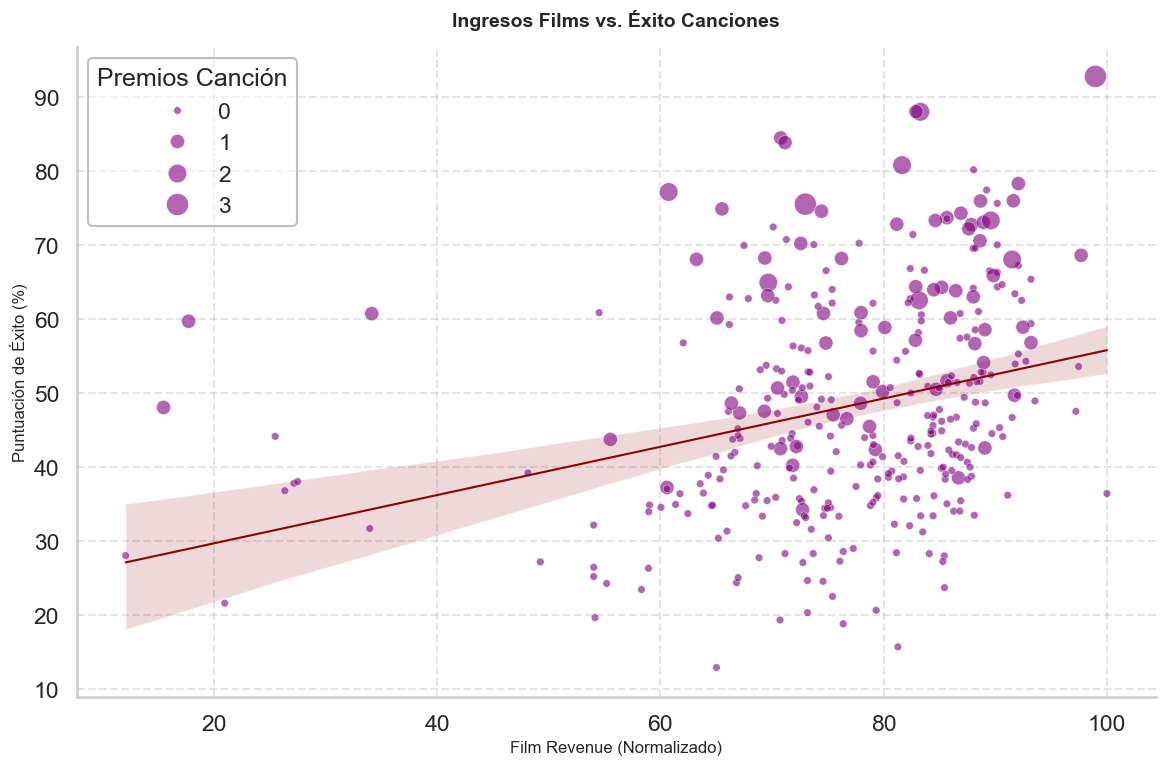

In [36]:
# Visualization Revenue vs Song Success

fig, ax = plt.subplots(figsize=(12, 8))

# Regression line
sns.regplot(
    data=df_final_analysis, 
    x='revenue_adjusted_normalized', 
    y='song_success_score', 
    scatter=False, 
    line_kws={'color': 'darkred', 'linewidth': 1.5},
    ax=ax
)

# Variable-sized scatter points on top
sns.scatterplot(
    data=df_final_analysis,
    x='revenue_adjusted_normalized',
    y='song_success_score',
    size='song_major_awards', 
    sizes=(30, 250),          # 0 awards = size 30, 3 awards = size 250
    alpha=0.6,                # Keeps overlapping bubbles visible
    color='purple',
    edgecolor='white',        # Adds a crisp border to make the bubbles pop
    ax=ax
)

# Labels and layout
plt.title('Ingresos Films vs. Éxito Canciones', fontsize=14, pad=15)
plt.xlabel('Film Revenue (Normalizado)', fontsize=12)
plt.ylabel('Puntuación de Éxito (%)', fontsize=12)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.2)
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.2)

plt.legend(
    title='Premios Canción', 
    loc='upper left', 
    frameon=True,
    facecolor='white',
    framealpha=0.5,
    edgecolor='gray'
)

plt.tight_layout() 
plt.savefig('plots/revenue_vs_song_success.png', dpi=300, bbox_inches='tight')
plt.show()

### Columna de Ranking

In [36]:
# Sort dataFrame by the primary score, then the tie-breaker
df_songs_films_merged = df_songs_films_merged.sort_values(
    by=['song_success_score', 'film_success_score'], 
    ascending=[False, False]
)

# Assign a 'dense' rank by grouping identical score combinations
df_songs_films_merged['success_rank'] = (
    df_songs_films_merged.groupby(['song_success_score', 'film_success_score'], sort=False)
    .ngroup() + 1
)

# View the top of the leaderboard to verify the ties and rankings
display(df_songs_films_merged[['success_rank', 'song_title', 'film_title', 'year_film','song_success_score', 'film_success_score']].head(25))

,success_rank,song_title,film_title,year_film,song_success_score,film_success_score
347,1,My Heart Will Go On,Titanic,1997,92.82,89.35
378,2,Lose Yourself,8 Mile,2002,88.05,71.36
325,3,Streets Of Philadelphia,Philadelphia,1993,88.03,79.59
39,4,White Christmas,Holiday Inn,1942,84.5,70.41
261,5,I Just Called To Say I Love You,The Woman In Red,1984,83.87,57.13
187,6,The Way We Were,The Way We Were,1973,80.82,73.9
317,7,(Everything I Do) I Do It For You,Robin Hood: Prince of Thieves,1991,80.19,50.84
331,8,Can You Feel The Love Tonight,The Lion King,1994,78.33,86.18
357,9,I Don't Want To Miss A Thing,Armageddon,1998,77.46,63.97
318,10,Tears In Heaven,Rush,1991,77.19,41.5


### Función de Búsqueda

In [43]:
def search_ranking(song_id=None, film_id=None, song_title=None, film_title=None, year=None, decade=None, artist=None):
    df_filtered = df_songs_films_merged.copy()
    
    # Exact matches for IDs
    if song_id is not None:
        df_filtered = df_filtered[df_filtered['song_id'] == song_id]
    if film_id is not None:
        df_filtered = df_filtered[df_filtered['film_id'] == film_id]
        
    # Exact match for year
    if year is not None:
        df_filtered = df_filtered[
            (df_filtered['year_song'] == year) | 
            (df_filtered['year_film'] == year)
        ]
    
    # Exact match for decade
    if decade is not None:
        df_filtered = df_filtered[
            (df_filtered['decade_song'] == decade)
        ]
        
    # Partial, case-insensitive matches for titles
    if song_title is not None:
        df_filtered = df_filtered[df_filtered['song_title'].str.contains(song_title, case=False, na=False)]
    if film_title is not None:
        df_filtered = df_filtered[df_filtered['film_title'].str.contains(film_title, case=False, na=False)]
        
    # Partial match across all four artist/composer columns
    if artist is not None:
        artist_mask = (
            df_filtered['original_artists'].str.contains(artist, case=False, na=False) |
            df_filtered['other_artists'].str.contains(artist, case=False, na=False) |
            df_filtered['song_composers'].str.contains(artist, case=False, na=False) |
            df_filtered['song_lyricists'].str.contains(artist, case=False, na=False)
        )
        df_filtered = df_filtered[artist_mask]
        
    # Select columns
    display_cols = [
        'song_title', 'film_title', 'year_film', 'original_artists',
        'success_rank', 'song_success_score', 'film_success_score', 
        'oscar_wins', 'song_major_awards', 'oscar_song_win',
        'streams_obs_max', 'revenue_adjusted', 'tmdb_tagline'
    ]
    
    # Return DataFrame
    final_df = df_filtered[display_cols].reset_index(drop=True)
    final_df.index = final_df.index + 1
    
    return final_df

In [29]:
display(search_ranking(film_title="titanic"))

,song_title,film_title,year_film,original_artists,success_rank,song_success_score,film_success_score,oscar_wins,song_major_awards,oscar_song_win,streams_obs_max,revenue_adjusted,tmdb_tagline
1,My Heart Will Go On,Titanic,1997,Céline Dion,1,92.82,89.35,11,3,True,714970000,4541627542,Nothing on earth could come between them.


In [43]:
display(search_ranking(artist='eminem'))

,song_title,film_title,year_film,original_artists,success_rank,song_success_score,film_success_score,oscar_wins,song_major_awards,oscar_song_win,streams_obs_max,revenue_adjusted,tmdb_tagline
1,Lose Yourself,8 Mile,2002,Eminem,2,88.05,71.36,1,1,True,2948917000,434641085,Every moment is another chance.


In [45]:
print(search_ranking(film_title="philadelphia").to_string())

                song_title    film_title  year_film   original_artists  success_rank  song_success_score  film_success_score  oscar_wins  song_major_awards  oscar_song_win  streams_obs_max  revenue_adjusted                                                                       tmdb_tagline
1  Streets Of Philadelphia  Philadelphia       1993  Bruce Springsteen             3               88.03               79.59           2                  2            True        491600000         460475273  No one would take on his case... until one man was willing to take on the system.
2             Philadelphia  Philadelphia       1993         Neil Young           313               39.53               79.59           2                  0           False           613000         460475273  No one would take on his case... until one man was willing to take on the system.


In [46]:
print(search_ranking(song_title='White Christmas').to_string())

        song_title   film_title  year_film original_artists  success_rank  song_success_score  film_success_score  oscar_wins  song_major_awards  oscar_song_win  streams_obs_max  revenue_adjusted     tmdb_tagline
1  White Christmas  Holiday Inn       1942      Bing Crosby             4                84.5               70.41           1                  1            True        659600000          74066641  WHAT A HOLIDAY!


In [48]:
print(search_ranking(artist='Stevie Wonder').to_string())

                        song_title        film_title  year_film               original_artists  success_rank  song_success_score  film_success_score  oscar_wins  song_major_awards  oscar_song_win  streams_obs_max  revenue_adjusted                                           tmdb_tagline
1  I Just Called To Say I Love You  The Woman In Red       1984                  Stevie Wonder             5               83.87               57.13           1                  1            True        646270000          78394205  He's head over heels and headed straight for trouble!
2               Gangsta's Paradise   Dangerous Minds       1995                         Coolio           136               55.63               41.53           0                  0           False       2574270000         379232379        She broke the rules... and changed their lives.
3                         It's You  The Woman In Red       1984  Stevie Wonder, Dionne Warwick           432               28.28              

In [47]:
print(search_ranking(decade=1960).head(10).to_string())

                           song_title                          film_title  year_film               original_artists  success_rank  song_success_score  film_success_score  oscar_wins  song_major_awards  oscar_song_win  streams_obs_max  revenue_adjusted                                                                                       tmdb_tagline
1                       Mrs. Robinson                        The Graduate       1967              Simon & Garfunkel            12               75.97               80.91           1                  1           False        800947000        1011569052                                          This is Benjamin. He’s a little worried about his future.
2                          Moon River              Breakfast at Tiffany's       1961  Audrey Hepburn, Henry Mancini            14               75.54                78.1           2                  3            True        129200000         102289582  Audrey Hepburn plays that daring, darling Hol

In [50]:
print(search_ranking(artist='Elton John').to_string())

                      song_title                  film_title  year_film                                           original_artists  success_rank  song_success_score  film_success_score  oscar_wins  song_major_awards  oscar_song_win  streams_obs_max  revenue_adjusted                                                               tmdb_tagline
1  Can You Feel The Love Tonight               The Lion King       1994                                                 Elton John             8               78.33               86.18           2                  1            True        427850000        1658496449  The greatest adventure of all is finding our place in the Circle of Life.
2                 Circle Of Life               The Lion King       1994                                                 Elton John            51               67.24               86.18           2                  0           False        278700000        1658496449  The greatest adventure of all is finding our pla

In [49]:
print(search_ranking(artist='Monty Python').to_string())

                               song_title                          film_title  year_film         original_artists  success_rank  song_success_score  film_success_score  oscar_wins  song_major_awards  oscar_song_win  streams_obs_max  revenue_adjusted                                                                                                tmdb_tagline
1  Always Look On The Bright Side Of Life                       Life of Brian       1979  Monty Python, Eric Idle           275               42.87               40.26           0                  0           False         59570000          92384568                                                             He's not the messiah...he's just a naughty boy.
2                             Galaxy Song  Monty Python's The Meaning of Life       1983  Monty Python, Eric Idle           372               35.15               45.41           0                  0           False         10657000         138182387  It took God six days to create th

In [51]:
print(search_ranking(artist='Henry Mancini').to_string())

                  song_title                      film_title  year_film                            original_artists  success_rank  song_success_score  film_success_score  oscar_wins  song_major_awards  oscar_song_win  streams_obs_max  revenue_adjusted                                                                                                              tmdb_tagline
1                 Moon River          Breakfast at Tiffany's       1961               Audrey Hepburn, Henry Mancini            14               75.54                78.1           2                  3            True        129200000         102289582                         Audrey Hepburn plays that daring, darling Holly Golightly to a new high in entertainment delight!
2     Days Of Wine And Roses          Days of Wine and Roses       1962                               Andy Williams            28               71.92                70.4           1                  3            True         30700000             21321 